In [ ]:
!pip install "numpy<2" scikit-learn-extra

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from scipy.interpolate import interp1d
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

# **Data Loading**

In [ ]:
m0 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/M0/JV.parquet')
p12 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/P12/JV.parquet')

## **EDA: Analysis of Voltage Sweep ($V_{span}$) and Validation Criteria**

Applying daytime filter (06:00 - 22:00)...


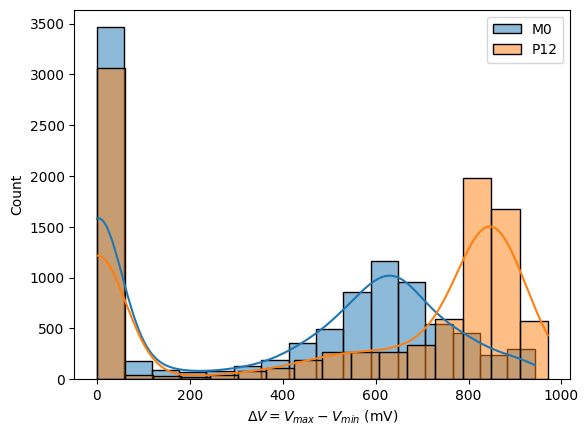

--- Analysis for Cell M0 ---
Total samples: 9572
First bin (0.0 to 58.9 mV):
 -> Count: 3463
 -> Percent: 36.18 %

--- Analysis for Cell P12 ---
Total samples: 9574
First bin (0.0 to 60.7 mV):
 -> Count: 3058
 -> Percent: 31.94 %

Full distribution table for M0 (first 10 rows):
    Start (mV)    End (mV)  Count  Percent (%)
0     0.000000   58.926875   3463    36.178437
1    58.926875  117.853750    182     1.901379
2   117.853750  176.780625     92     0.961137
3   176.780625  235.707500     76     0.793982
4   235.707500  294.634375     77     0.804430
5   294.634375  353.561250    130     1.358128
6   353.561250  412.488125    191     1.995403
7   412.488125  471.415000    361     3.771417
8   471.415000  530.341875    495     5.171333
9   530.341875  589.268750    859     8.974091
10  589.268750  648.195625   1160    12.118679
11  648.195625  707.122500    957     9.997911
12  707.122500  766.049375    546     5.704137
13  766.049375  824.976250    451     4.711659
14  824.976250  

In [ ]:
def analyze_histogram(data, name, n_bins='auto'):
    # 1. Safety drop NaNs
    data = data.dropna()
    total = len(data)

    # 2. Compute histogram (counts and edges)
    counts, bin_edges = np.histogram(data, bins=n_bins)

    # 3. Create DataFrame for visualization
    df_hist = pd.DataFrame({
        'Start (mV)': bin_edges[:-1],
        'End (mV)': bin_edges[1:],
        'Count': counts,
        'Percent (%)': (counts / total) * 100
    })

    # 4. Print stats for the first bin
    print(f"--- Analysis for {name} ---")
    print(f"Total samples: {total}")
    print(f"First bin ({bin_edges[0]:.1f} to {bin_edges[1]:.1f} mV):")
    print(f" -> Count: {counts[0]}")
    print(f" -> Percent: {(counts[0] / total) * 100:.2f} %\n")

    return df_hist

# 1. Processing M0
jv_0 = m0.copy()
jv_0['curve'] = (jv_0['integer4725'] == jv_0['integer4725'].min()).cumsum()
jv_0.loc[np.mod(jv_0['curve'], 2) == 0, 'curve'] -= 1
jv_0.loc[:, 'curve'] = ((jv_0.loc[:, 'curve'] - 1) / 2 + 1).astype('int')

# 2. Processing P12
jv_12 = p12.copy()
jv_12['curve'] = (jv_12['integer4725'] == jv_12['integer4725'].min()).cumsum()
jv_12.loc[np.mod(jv_12['curve'], 2) == 0, 'curve'] -= 1
jv_12.loc[:, 'curve'] = ((jv_12.loc[:, 'curve'] - 1) / 2 + 1).astype('int')

jv_0.insert(0, 'cell_id', 0)
jv_12.insert(0, 'cell_id', 1)

# 3. Concatenation
jv = pd.concat([jv_0, jv_12], axis=0)

# 4. Sweep Direction Identification
jv['int_diff'] = jv['integer4725'].diff().bfill()
jv['is_forward'] = np.where(jv['int_diff'] < 0, 1, 0)

# 5. Global Curve ID Assignment
jv['id_curve'] = jv['curve']
jv.loc[(jv['cell_id'] == 1), 'id_curve'] += jv.loc[(jv['cell_id'] == 0), 'curve'].max()

# 6. Temporal Filtering: Daylight hours (6 AM - 10 PM)
print("Applying daytime filter (06:00 - 22:00)...")
jv['time'] = pd.to_datetime(jv['time'])
jv = jv[jv['time'].dt.time.between(pd.to_datetime('06:00').time(), pd.to_datetime('22:00').time())]

# 7. Voltage Span Calculation (Vmax - Vmin)
volt_diff_0 = jv[jv['cell_id'] == 0].groupby('id_curve')['voltage'].agg(np.ptp)
volt_diff_1 = jv[jv['cell_id'] == 1].groupby('id_curve')['voltage'].agg(np.ptp)

# 8. Plot & Analyze
visual_bins = 16

# Histogram Plot
sns.histplot(volt_diff_0, kde=True, label='M0', bins=visual_bins)
sns.histplot(volt_diff_1, kde=True, label='P12', bins=visual_bins)
plt.xlabel(r'$\Delta V = V_{max} - V_{min} \text{ (mV)}$')
plt.legend()
plt.show()

# Run Analysis
df_m0 = analyze_histogram(volt_diff_0, "Cell M0", n_bins=visual_bins)
df_p12 = analyze_histogram(volt_diff_1, "Cell P12", n_bins=visual_bins)

print("Full distribution table for M0 (first 10 rows):")
print(df_m0)
print("\nFull distribution table for P12 (first 10 rows):")
print(df_p12)

# **Processing: Curve Identification and Validation**

In [ ]:
def process_jv_curves(m0, p12, v_span_threshold):
    """
    Reads two parquet files, processes JV curves, identifies sweep directions,
    and calculates curve validity based on voltage span.

    Args:
        m0 (pd.DataFrame): Data for cell 0.
        p12 (pd.DataFrame): Data for cell 1.
        v_span_threshold (int): Minimum voltage range for a curve to be valid.

    Returns:
        pd.DataFrame: Combined and processed DataFrame.
    """

    # Helper function to process curve identification (common to both)
    def _process_individual(df_input, cell_id):
        df = df_input.copy()

        # If 'time' is a column, set it as index
        if 'time' in df.columns:
            df.set_index('time', inplace=True)

        # Insert Cell ID
        df.insert(0, 'cell_id', cell_id)

        # Curve identification
        df['curve'] = (df['integer4725'] == df['integer4725'].min()).cumsum()
        df.loc[np.mod(df['curve'], 2) == 0, 'curve'] -= 1
        df['curve'] = ((df['curve'] - 1) / 2 + 1).astype(int)

        return df

    # 1. Individual processing
    jv_0 = _process_individual(m0, 0)
    jv_12 = _process_individual(p12, 1)

    # 2. Concatenation
    jv = pd.concat([jv_0, jv_12], axis=0)

    # 3. current_density
    jv['current_density'] = jv['power'] / jv['voltage'] * 1000  # A/cm2 -> mA/cm2

    # 4. Direction assignment (1: Forward, 0: Reverse)
    jv['int_diff'] = jv['integer4725'].diff()
    jv.loc[jv['int_diff'] == 0, 'int_diff'] = np.nan
    jv['int_diff'] = jv['int_diff'].bfill()
    jv.loc[jv['int_diff'] > 0, 'int_diff'] = 0
    jv.loc[jv['int_diff'] < 0, 'int_diff'] = 1
    jv['int_diff'] = jv['int_diff'].astype(int)
    jv.rename(columns={'int_diff' : 'is_forward'}, inplace=True)

    # 5. Global Curve ID
    jv['id_curve'] = jv['curve']
    max_curve_0 = jv.loc[jv['cell_id'] == 0, 'curve'].max()
    jv.loc[jv['cell_id'] == 1, 'id_curve'] += max_curve_0

    # 6. Voltage Span calculation and Validity (Filter)
    v_span = jv.groupby('id_curve')['voltage'].transform(lambda x: x.max() - x.min())
    jv['v_span'] = v_span
    jv['is_curve_valid'] = (jv['v_span'] > v_span_threshold).astype(int)

    return jv

In [ ]:
jv = process_jv_curves(m0, p12, 200)

In [ ]:
jv

,cell_id,integer4725,voltage,power,curve,current_density,is_forward,id_curve,v_span,is_curve_valid
time,,,,,,,,,,
2025-09-22 18:36:33.331315,0,1250,720.87,0.187500,1,0.260102,0,1,743.41,1
2025-09-22 18:36:33.512825,0,1255,737.40,0.203125,1,0.275461,0,1,743.41,1
2025-09-22 18:36:33.658098,0,1260,745.80,0.203125,1,0.272359,0,1,743.41,1
2025-09-22 18:36:33.803219,0,1265,751.54,0.218750,1,0.291069,0,1,743.41,1
2025-09-22 18:36:33.948513,0,1270,756.07,0.218750,1,0.289325,0,1,743.41,1
...,...,...,...,...,...,...,...,...,...,...
2025-11-11 22:00:37.598048,1,1270,27.38,0.000000,14303,0.000000,1,28589,0.02,0
2025-11-11 22:00:37.740749,1,1265,27.38,0.000000,14303,0.000000,1,28589,0.02,0
2025-11-11 22:00:37.885717,1,1260,27.38,-0.000000,14303,-0.000000,1,28589,0.02,0


# **JV Photovoltaic Parameter Extraction: Daily Pmax, Vmpp, Jmpp, Voc, & Jsc (EDA Simple Approximation: Max/Min)**

In [ ]:
def jv_cell_visualization(jv, cell_id):
  df = jv.loc[jv['cell_id'] == cell_id, :]

  if 'time' in df.columns:
    df.set_index('time', inplace=True)

  df.index = df.index.date
  df.index.name='time'
  days = np.unique(df.index)
  best_days = df.groupby(df.index).apply(lambda x: x.loc[x['power'] == x['power'].max()].max()).sort_values('power', ascending=False)

  return df, days, best_days

In [ ]:
def plot_curves(jv, cell_id, filter, plot_pow_den_curves, plot_parameters):
    df, days, best_days = jv_cell_visualization(jv, cell_id)

    if df['cell_id'].unique() == 0:
        cell_id = 'M0'
    else:
        cell_id = 'P12'

    k_values = list(range(0, len(days)))
    id_curve = []
    DPM = []
    Vmpp = []
    Jmpp = []
    Voc = []
    Jsc = []
    d = []

    for k in k_values:
        best_day_k = df.loc[df.index == days[k], :]
        best_day_k_curves = best_day_k.groupby('curve')['power'].max()
        best_day_k_curves.sort_values(ascending=False, inplace=True)
        best_day_k_best_curve = best_day_k.groupby('time').apply(lambda x: x.loc[x['curve'] == best_day_k_curves.index[0]])

        # ------------------------------------------------------------------------------------------------
        # FILTER
        # ------------------------------------------------------------------------------------------------
        if filter == True and best_day_k_best_curve.is_curve_valid.sum() == 0:
            for c in range(1, len(best_day_k_curves.index)):
                best_day_k_best_curve = best_day_k.groupby('time').apply(lambda x: x.loc[x['curve'] == best_day_k_curves.index[c]])

                if best_day_k_best_curve.power.sum() != 0:
                    d.append(k)
                    id_curve.append(best_day_k_best_curve.id_curve.iloc[0].item())
                    DPM.append(best_day_k_best_curve.power.max())
                    Vmpp.append(best_day_k_best_curve.groupby('time').apply(lambda x: x.loc[x['power'] == x['power'].max()])['voltage'].iloc[0].item())
                    Jmpp.append(best_day_k_best_curve.groupby('time').apply(lambda x: x.loc[x['power'] == x['power'].max()])['current_density'].iloc[0].item())
                    Voc.append(best_day_k_best_curve.voltage.max())
                    Jsc.append(best_day_k_best_curve['current_density'].max())

                    if plot_pow_den_curves == True:
                        fig, ax1 = plt.subplots(figsize=(16, 6))
                        ax1.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['power'], label='Power Density', color='tab:blue', marker='o', linewidth=2)
                        ax1.set_xlabel('Voltage (mV)', fontsize=16)
                        ax1.set_ylabel('Power Density (mW/cm$^{2}$)', color='tab:blue', fontsize=16)
                        ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=14)
                        ax1.tick_params(axis='x', labelsize=14)
                        plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

                        ax2 = ax1.twinx()
                        ax2.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['current_density'], label='Current Density', color='tab:red', marker='x', linewidth=2)
                        ax2.set_ylabel('Current Density (mA/cm$^2$)', color='tab:red', fontsize=16)
                        ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=14)
                        plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

                        ax1.legend(loc='upper left')
                        ax2.legend(loc='upper right')
                        plt.title(f'Power and Current Density Curves for the day {days[k]} ({k+1}) ({cell_id}) (Filtered)', fontsize=14, fontweight='bold')
                        plt.tight_layout()
                        plt.show()
                    break
        else:
            # -------------------------------------------------------------------------------------------------
            d.append(k)
            id_curve.append(best_day_k_best_curve.id_curve.iloc[0].item())
            DPM.append(best_day_k_best_curve.power.max())
            Vmpp.append(best_day_k_best_curve.groupby('time').apply(lambda x: x.loc[x['power'] == x['power'].max()])['voltage'].iloc[0].item())
            Jmpp.append(best_day_k_best_curve.groupby('time').apply(lambda x: x.loc[x['power'] == x['power'].max()])['current_density'].iloc[0].item())
            Voc.append(best_day_k_best_curve.voltage.max())
            Jsc.append(best_day_k_best_curve['current_density'].max())

            if plot_pow_den_curves == True:
                fig, ax1 = plt.subplots(figsize=(16, 6))
                ax1.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['power'], label='Power Density', color='tab:blue', marker='o', linewidth=2)
                ax1.set_xlabel('Voltage (mV)', fontsize=16)
                ax1.set_ylabel('Power Density (mW/cm$^{2}$)', color='tab:blue', fontsize=16)
                ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=14)
                ax1.tick_params(axis='x', labelsize=14)
                plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

                ax2 = ax1.twinx()
                ax2.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['current_density'], label='Current Density', color='tab:red', marker='x', linewidth=2)
                ax2.set_ylabel('Current Density (mA/cm$^2$)', color='tab:red', fontsize=16)
                ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=14)
                plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

                ax1.legend(loc='upper left')
                ax2.legend(loc='upper right')
                plt.title(f'Power and Current Density Curves for the day {days[k]} ({k+1}) ({cell_id})', fontsize=14, fontweight='bold')
                plt.tight_layout()
                plt.show()

    df_all = pd.DataFrame({
        'time': [days[i] for i in d],
        'id_curve': id_curve,
        'DPM': DPM,
        'Vmpp': Vmpp,
        'Jmpp': Jmpp,
        'Voc': Voc,
        'Jsc': Jsc,
        'FF': (np.array(Vmpp) * np.array(Jmpp)) / (np.array(Voc) * np.array(Jsc)),
        'FFv': np.array(Vmpp) / np.array(Voc),
        'FFj': np.array(Jmpp) / np.array(Jsc)
    })
    df_all.set_index('time', inplace=True)

    if plot_parameters == True:
        title_font = {'weight': 'bold', 'size': 16}
        label_font = {'weight': 'normal', 'size': 14}
        tick_size = 12

        # --- CAMBIO A MATRIZ 2x2 ---
        fig, axs = plt.subplots(2, 2, figsize=(16, 12))
        axs = axs.flatten()

        axs[0].plot(df_all.index, df_all['DPM'], marker='o')
        axs[0].grid(True)
        axs[0].set_ylabel('Power (mW/cm$^2$)', fontdict=label_font)
        axs[0].set_title(f'Daily Power Max ({cell_id})', fontdict=title_font)
        axs[0].tick_params(axis='both', which='major', labelsize=tick_size)

        axs[1].plot(df_all.index, df_all['Voc'], marker='o', color='cyan', label='Voc')
        axs[1].plot(df_all.index, df_all['Vmpp'], marker='o', color='blue', label='Vmpp')
        axs[1].grid(True)
        axs[1].set_ylabel('Voltage (mV/cm$^2$)', fontdict=label_font)
        axs[1].set_title(f'Voc & Vmpp ({cell_id})', fontdict=title_font)
        axs[1].legend(loc='upper right', fontsize=12)
        axs[1].tick_params(axis='both', which='major', labelsize=tick_size)

        axs[2].plot(df_all.index, df_all['Jsc'], marker='o', color='mediumseagreen', label='Jsc')
        axs[2].plot(df_all.index, df_all['Jmpp'], marker='o', color='darkgreen', label='Jmpp')
        axs[2].grid(True)
        axs[2].set_ylabel('Current Density (mA/cm$^2$)', fontdict=label_font)
        axs[2].set_title(f'Jsc & Jmpp ({cell_id})', fontdict=title_font)
        axs[2].legend(loc='upper right', fontsize=12)
        axs[2].tick_params(axis='both', which='major', labelsize=tick_size)

        axs[3].plot(df_all.index, df_all['FF'], label='FF', marker='o', color='purple')
        axs[3].plot(df_all.index, df_all['FFv'], label='FFv', marker='s', color='magenta')
        axs[3].plot(df_all.index, df_all['FFj'], label='FFj', marker='^', color='orange')
        axs[3].grid(True)
        axs[3].set_ylabel('FF', fontdict=label_font)
        axs[3].set_title(f'FF, FFv, and FFj ({cell_id})', fontdict=title_font)
        axs[3].legend(fontsize=12)
        axs[3].tick_params(axis='both', which='major', labelsize=tick_size)

        fig.autofmt_xdate(rotation=45)
        plt.tight_layout()
        plt.show()

    return df_all

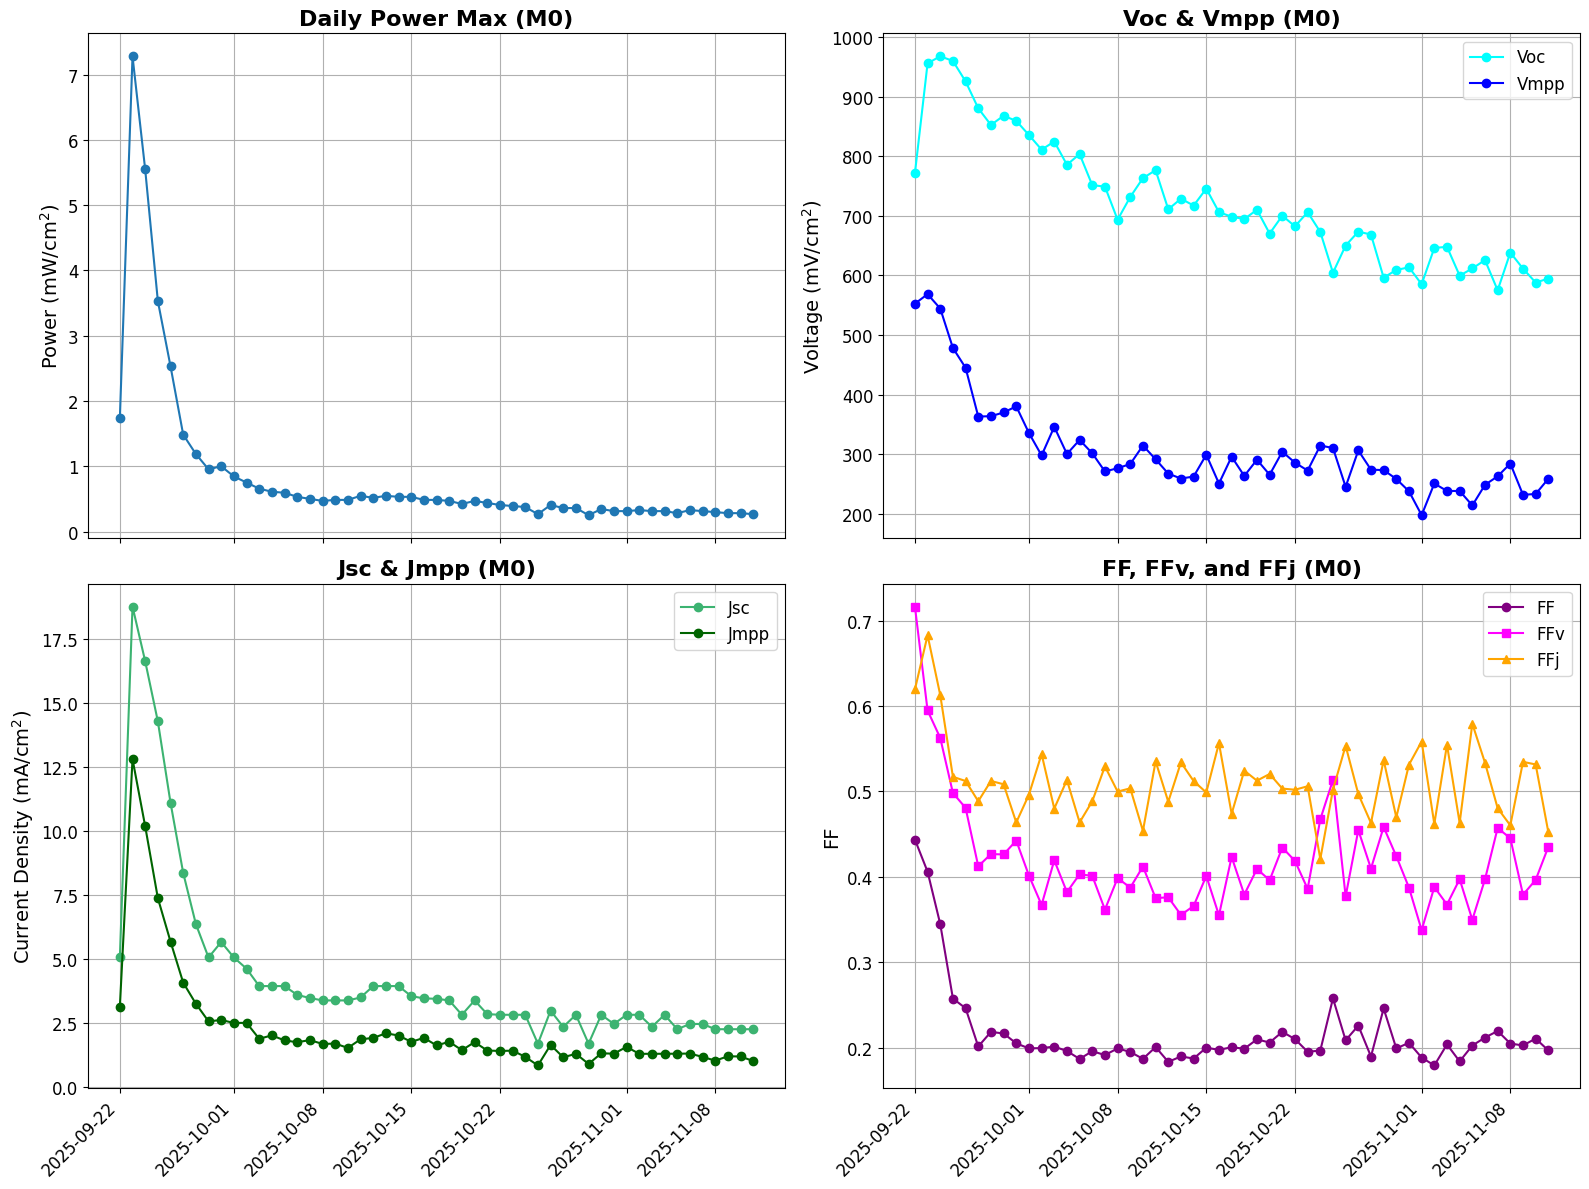

In [ ]:
df_all = plot_curves(jv, cell_id= 0, filter=True, plot_pow_den_curves=False, plot_parameters=True)

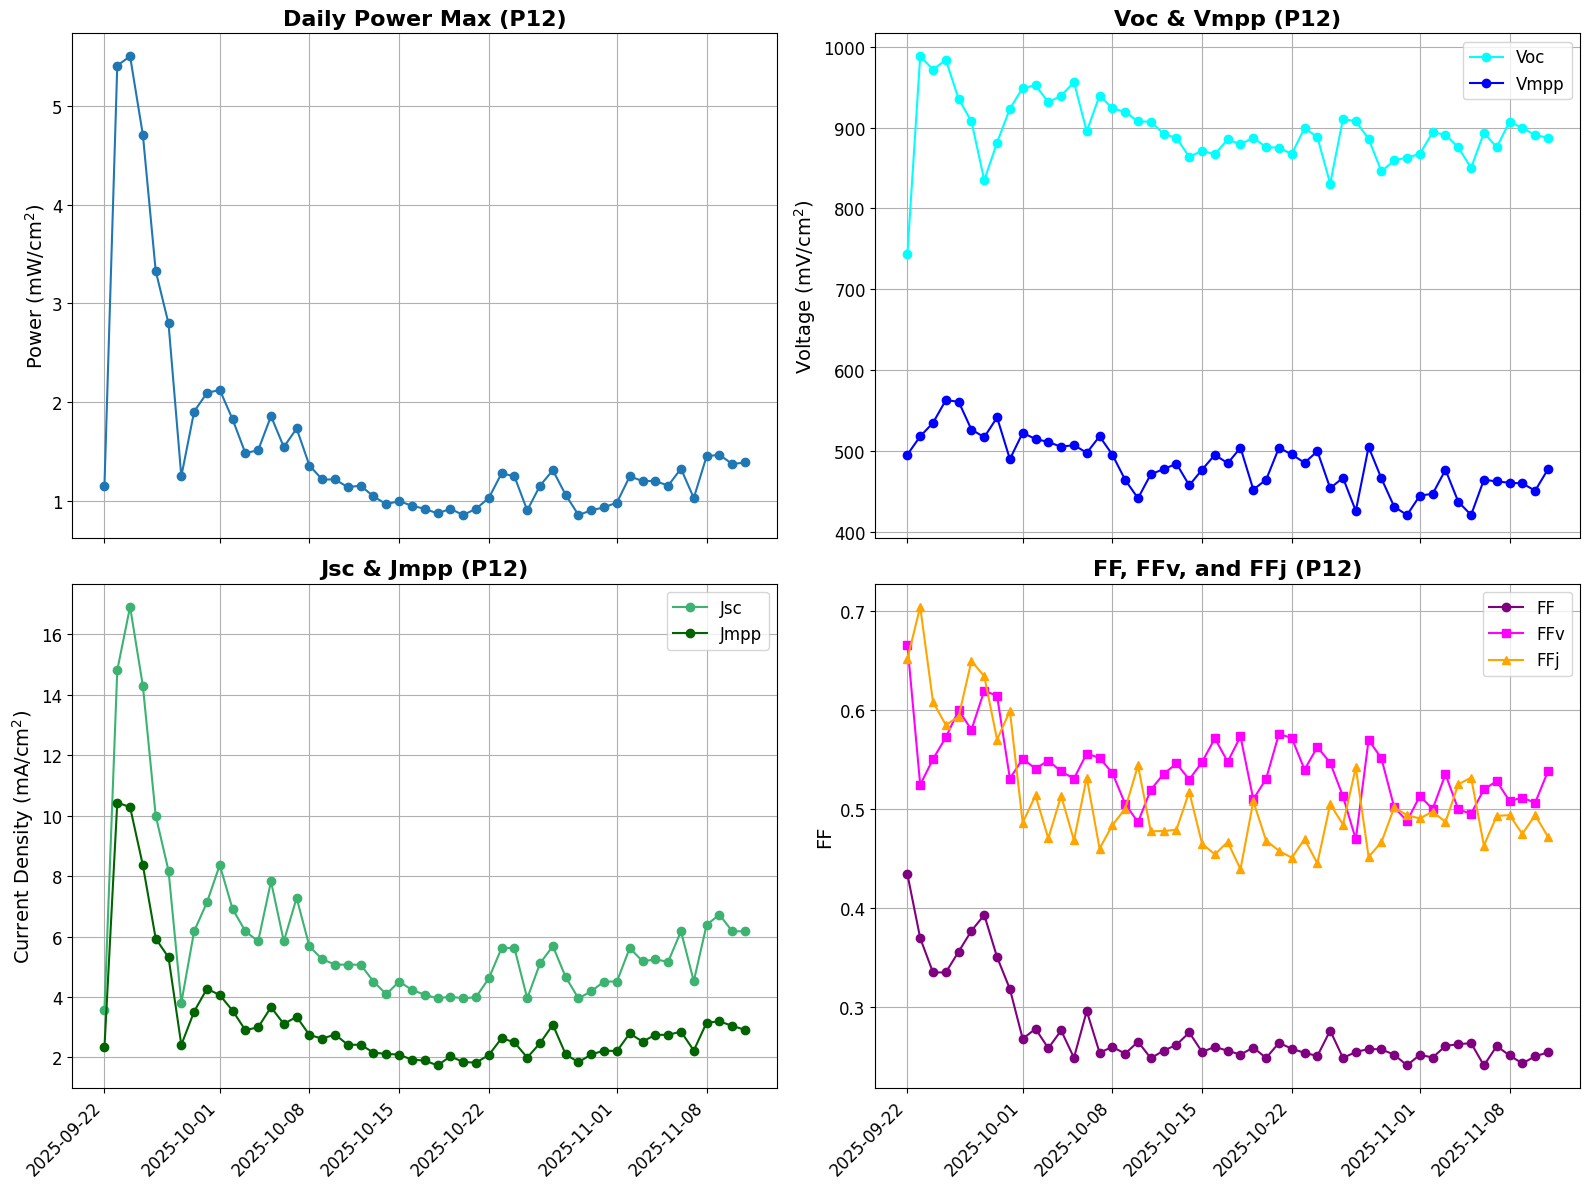

In [ ]:
df_all = plot_curves(jv, cell_id= 1, filter=True, plot_pow_den_curves=False, plot_parameters=True)

$$ FF = \frac{V_{mpp} \cdot J_{mpp}}{V_{oc} \cdot J_{sc}}, \quad FF_v = \frac{V_{mpp}}{V_{oc}}, \quad FF_j = \frac{J_{mpp}}{J_{sc}} $$


In [ ]:
df_all

,id_curve,DPM,Vmpp,Jmpp,Voc,Jsc,FF,FFv,FFj
time,,,,,,,,,
2025-09-22,14288,1.156250,495.56,2.333219,744.07,3.580431,0.434013,0.666013,0.651659
2025-09-23,14495,5.406250,518.17,10.433352,988.19,14.813027,0.369328,0.524363,0.704336
2025-09-24,14796,5.500000,534.83,10.283642,971.81,16.912535,0.334636,0.550344,0.608049
2025-09-25,15060,4.703125,562.95,8.354428,983.66,14.284459,0.334717,0.572301,0.584861
2025-09-26,15330,3.328125,560.90,5.933544,935.40,10.001778,0.355734,0.599637,0.593249
2025-09-27,15610,2.796875,526.45,5.312708,907.66,8.178589,0.376766,0.580008,0.649587
2025-09-28,15883,1.250000,517.16,2.417047,834.86,3.811905,0.392784,0.619457,0.634078
2025-09-29,16208,1.906250,541.51,3.520249,881.53,6.175889,0.350141,0.614284,0.569999
2025-09-30,16464,2.093750,489.97,4.273221,923.26,7.132787,0.317937,0.530696,0.599096


# **JV Photovoltaic Parameter Extraction: Daily Pmax, Vmpp, Jmpp, Voc, & Jsc (Smoothing and Regression)**

In [ ]:
def extract_physics_parameters(jv):
    # 1. Prepare and sort data
    # Remove exact duplicates to avoid regression issues, keeping the average
    # (Optional, but helpful if there are many repeated zeros)
    jv = jv.sort_values(by='voltage')

    V = jv['voltage'].values
    P = jv['power'].values
    J = jv['current_density'].values

    results = {
        'voc': np.nan, 'jsc': np.nan,
        'p_mpp': np.nan, 'v_mpp': np.nan, 'j_mpp': np.nan,
        'ff': np.nan, 'ff_v': np.nan, 'ff_j': np.nan,
        'error_flag_voc': 0, 'error_flag_jsc': 0, 'error_flag_mpp': 0,
        'error_flag_vmpp': 0,  'error_flag_jmpp': 0,
        'error_flag_ff': 0, 'error_flag_ffv': 0, 'error_flag_ffj': 0
    }

    # --- A. MPP, VMPP, JMPP EXTRACTION (Smoothing) ---
    try:
        window = min(11, len(V))
        if window % 2 == 0: window -= 1

        if window > 3:
            P_smooth = savgol_filter(P, window_length=window, polyorder=2)
        else:
            P_smooth = P

        mpp_idx = np.argmax(P_smooth)
        results['p_mpp'] = P_smooth[mpp_idx]
        results['v_mpp'] = V[mpp_idx]
        results['j_mpp'] = J[mpp_idx]

        if results['p_mpp'] < 0:
              results['error_flag_mpp'] = np.nan # flag
        if results['v_mpp'] < 0:
              results['error_flag_vmpp'] = np.nan # flag
        if results['j_mpp'] < 0:
              results['error_flag_jmpp'] = np.nan # flag

    except Exception:
        results['error_flag_mpp'] = np.nan # flag

    # --- B. Voc EXTRACTION (Crossing at J=0) ---
    try:
        idx_j0 = np.argsort(np.abs(J))[:5] # 5 indices of J values closest to J=0
        subset_V_voc = V[idx_j0]
        subset_J_voc = J[idx_j0]

        # ANTI-CRASH CRITERIA:
        if np.max(subset_J_voc) - np.min(subset_J_voc) < 1e-13:
            results['voc'] = np.mean(subset_V_voc)
        else:
            # Fit V vs I to obtain Voc as the intercept
            slope, intercept, _, _, _ = linregress(subset_J_voc, subset_V_voc)
            results['voc'] = intercept

        # Sanity Check
        if not np.isnan(results['voc'] and not np.isnan(np.mean(subset_V_voc)) and
            np.mean(subset_V_voc) != 0 and results['voc'] / np.mean(subset_V_voc) >= 1.5):

            results['voc'] = np.mean(subset_V_voc)

    except Exception:
        # If it fails for any other reason, NaN
        results['voc'] = np.nan
        results['error_flag_voc'] = np.nan # flag

    # --- C. Jsc EXTRACTION (Crossing at V=0) ---
    try:
        idx_v0 = np.argsort(np.abs(V))[:5] # 5 indices of V values closest to V=0
        subset_V = V[idx_v0]
        subset_J = J[idx_v0]

        # ANTI-CRASH CRITERIA:
        if np.max(subset_V) - np.min(subset_V) < 1e-13:
            results['jsc'] = np.mean(subset_J)
        else:
            slope, intercept, _, _, _ = linregress(subset_V, subset_J)
            if intercept < 0: # if jsc is negative, take the mean
               results['jsc'] = np.mean(subset_J)
            else:
              results['jsc'] = intercept

        # Sanity Check
        if not np.isnan(results['jsc'] and not np.isnan(np.mean(subset_J)) and
            np.mean(subset_J) != 0 and results['jsc'] / np.mean(subset_J) >= 1.5):

            results['jsc'] = np.mean(subset_J)

    except Exception:
        results['jsc'] = np.nan
        results['error_flag_jsc'] = np.nan # flag

    # --- D. CALCULATION OF FF, FFV, FFJ ---
    if (results['voc'] != 0) and (results['jsc'] != 0) \
       and not np.isnan(results['voc']) and not np.isnan(results['jsc']):
        results['ff'] = (results['v_mpp'] * results['j_mpp']) / (results['voc'] * results['jsc'])

    if (results['v_mpp'] != 0) and (results['voc'] != 0) \
       and not np.isnan(results['v_mpp']) and not np.isnan(results['voc']):
        results['ff_v'] = results['v_mpp'] / (results['voc'])

    if (results['j_mpp'] != 0) and (results['jsc'] != 0) \
       and not np.isnan(results['j_mpp']) and not np.isnan(results['jsc']):
        results['ff_j'] = results['j_mpp'] / (results['jsc'])

    # Sanity Check
    if results['ff'] > 1.0 or results['ff'] < 0:
        results['ff'] = np.nan
        results['error_flag_ff'] = np.nan # flag

    if results['ff_v'] > 1.0 or results['ff_v'] < 0:
        results['ff_v'] = np.nan
        results['error_flag_ffv'] = np.nan # flag

    if results['ff_j'] > 1.0 or results['ff_j'] < 0:
        results['ff_j'] = np.nan
        results['error_flag_ffj'] = np.nan # flag

    return pd.Series(results)

# **Outlier Detection and Cleaning**

In [ ]:
def params_outliers_iqr(params_df):
    cols_to_check = [
        'voc', 'jsc', 'p_mpp', 'v_mpp', 'j_mpp',
        'ff', 'ff_v', 'ff_j'
    ]

    df = params_df.copy()

    # Iterate over the columns
    for col in tqdm(cols_to_check, desc="Flagging Outliers"):

        # 1. Correct grouping (Cell + Direction)
        grouped = df.groupby(['cell_id', 'is_forward'])[col]

        Q1 = grouped.transform(lambda x: x.quantile(0.25))
        Q3 = grouped.transform(lambda x: x.quantile(0.75))
        IQR = Q3 - Q1

        # 2. DEFINE MULTIPLIERS (Asymmetric Logic)
        # ---------------------------------------------------------
        # Current and Power:
        # Strict lower bound (1.5) to detect drops to zero/failures.
        if col == 'jsc':
            lower_mult = 1.5
            upper_mult = 15.0

        elif col == 'j_mpp':
            lower_mult = 1.5
            upper_mult = 20.0

        elif col == 'p_mpp':
            # Lax upper bound (60.0) to avoid flagging high "beginning of life" as outliers.
            lower_mult = 1.5
            upper_mult = 60.0
        else:
            # Voc/Vmpp and FFs:
            # Symmetric to eliminate noise in both directions.
            lower_mult = 5.0
            upper_mult = 5.0

        lower_bound = Q1 - lower_mult * IQR
        upper_bound = Q3 + upper_mult * IQR

        # 3. Create column name and initialize to 0
        outlier_col_name = f'outlier_{col}'
        df[outlier_col_name] = 0

        # 4. STATISTICAL MASK
        mask_iqr = (df[col] < lower_bound) | (df[col] > upper_bound)

        # 5. PHYSICAL MASK (Integrated Hard Limits)
        mask_physical = False # Default

        if col == 'voc':
            mask_physical = df[col] > 1300  # Voc physical limit
        elif col == 'jsc':
            mask_physical = df[col] > 100   # Jsc physical limit
        elif col == 'p_mpp':
            mask_physical = df[col] < 0     # Negative power impossible

        # 6. MASK UNION
        final_mask = mask_iqr | mask_physical

        # 7. ASSIGN THE FLAG (1)
        # Use .loc to ensure writing to the DataFrame
        if final_mask.sum() > 0:
            df.loc[final_mask, outlier_col_name] = 1
            # print(f"   -> {outlier_col_name}: {final_mask.sum()} flags.")

    return df

In [ ]:
def get_curves_params(jv):
    """
    Executes the physical parameter extraction pipeline, visualizes errors,
    and cleans invalid curves.
    """
    # Initialize tqdm for pandas
    tqdm.pandas()

    # --- 1. Data Preparation and Pipeline Execution ---
    if not jv.index.name == 'time':
      jv_time = jv.time
    else:
      jv_time = jv.index

    valid_data = jv[jv['is_curve_valid'] == 1].copy()

    params_df = valid_data.groupby(['cell_id', 'id_curve', 'is_forward']).progress_apply(
        lambda x: extract_physics_parameters(x),
        include_groups=False
    ).reset_index()

    # --- 2. Initial Error Identification (Visualization) ---
    errors = params_df.isnull().sum()
    if errors.sum() > 0:
        print(f"\nNaNs found:\n{errors[errors > 0]}")
        sns.barplot(x=errors[errors > 0].index, y=errors[errors > 0].values)
        plt.title("Errors detected by parameter")
        plt.show()
    else:
        print("\nNo initial NaNs found.")

    # --- 3. Cleaning and Index Update ---
    print('Removing invalid curves...')

    # Identify rows with NaNs
    df_err = params_df[params_df.isnull().any(axis=1)]

    if not df_err.empty:
        not_valid_curves_idx = df_err.set_index(['cell_id', 'id_curve']).index

        # Synchronize DataFrames using indices
        jv.set_index(['cell_id', 'id_curve'], inplace=True)
        params_df.set_index(['cell_id', 'id_curve'], inplace=True)

        # Mark as invalid in the original DF and remove from parameters
        jv.loc[not_valid_curves_idx, 'is_curve_valid'] = 0  # Update jv
        params_df.drop(index=not_valid_curves_idx, inplace=True)
        print(f"Cleanup completed: {len(not_valid_curves_idx)} curves invalidated in 'jv' and removed from 'params_df'.")

        # Restore indices
        params_df.reset_index(inplace=True)
        jv.reset_index(inplace=True)

        if 'time' not in jv.columns:
         jv.insert(0, 'time', jv_time)

    else:
        print("No invalid curves to remove.")

    # --- 4. Final Verification ---
    final_errors = params_df.isnull().sum()
    if final_errors.sum() > 0:
        print(f"Remaining errors:\n{final_errors[final_errors > 0]}")
    else:
        print("Cleanup completed: No NaNs remaining in params_df.")

    params_df.drop(['error_flag_voc', 'error_flag_jsc', 'error_flag_mpp', 'error_flag_vmpp',  \
                    'error_flag_jmpp',  'error_flag_ff',  'error_flag_ffv', 'error_flag_ffj'], axis=1, inplace=True)

    # --- 5. Outliers ---
    params_df = params_outliers_iqr(params_df)

    return jv, params_df


100%|██████████| 24472/24472 [00:58<00:00, 416.97it/s]


NaNs found:
ff                 630
ff_v              1083
ff_j               564
error_flag_ff      133
error_flag_ffv    1083
error_flag_ffj      67
dtype: int64


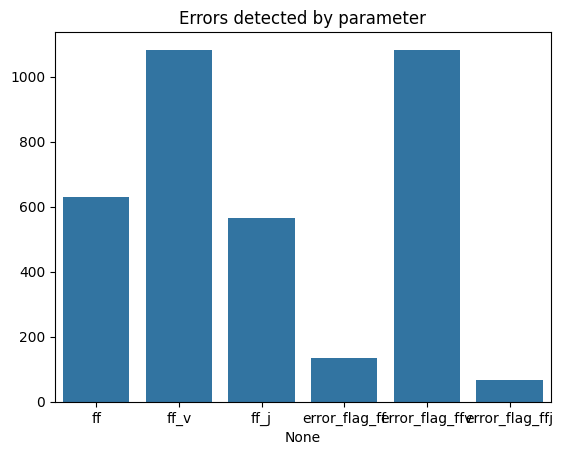

Removing invalid curves...
Cleanup completed: 1120 curves invalidated in 'jv' and removed from 'params_df'.
Cleanup completed: No NaNs remaining in params_df.


Flagging Outliers: 100%|██████████| 8/8 [00:00<00:00, 47.34it/s]


In [ ]:
jv, params_df = get_curves_params(jv)

In [ ]:
jv

,time,cell_id,id_curve,integer4725,voltage,power,curve,current_density,is_forward,v_span,is_curve_valid
0,2025-09-22 18:36:33.331315,0,1,1250,720.87,0.187500,1,0.260102,0,743.41,1
1,2025-09-22 18:36:33.512825,0,1,1255,737.40,0.203125,1,0.275461,0,743.41,1
2,2025-09-22 18:36:33.658098,0,1,1260,745.80,0.203125,1,0.272359,0,743.41,1
3,2025-09-22 18:36:33.803219,0,1,1265,751.54,0.218750,1,0.291069,0,743.41,1
4,2025-09-22 18:36:33.948513,0,1,1270,756.07,0.218750,1,0.289325,0,743.41,1
...,...,...,...,...,...,...,...,...,...,...,...
4860125,2025-11-11 22:00:37.598048,1,28589,1270,27.38,0.000000,14303,0.000000,1,0.02,0
4860126,2025-11-11 22:00:37.740749,1,28589,1265,27.38,0.000000,14303,0.000000,1,0.02,0
4860127,2025-11-11 22:00:37.885717,1,28589,1260,27.38,-0.000000,14303,-0.000000,1,0.02,0
4860128,2025-11-11 22:00:38.031735,1,28589,1255,27.38,-0.000000,14303,-0.000000,1,0.02,0


In [ ]:
params_df

,cell_id,id_curve,is_forward,voc,jsc,p_mpp,v_mpp,j_mpp,ff,ff_v,ff_j,outlier_voc,outlier_jsc,outlier_p_mpp,outlier_v_mpp,outlier_j_mpp,outlier_ff,outlier_ff_v,outlier_ff_j
0,0,1,0,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341,0,0,0,0,0,0,0,0
1,0,1,1,732.548,4.618782,1.076887,378.26,2.850222,0.318644,0.516362,0.617094,0,0,0,0,0,0,0,0
2,0,2,0,750.842,4.511007,1.644996,521.61,3.085399,0.475155,0.694700,0.683971,0,0,0,0,0,0,0,0
3,0,2,1,723.854,4.511007,0.984776,397.44,2.476789,0.301464,0.549061,0.549055,0,0,0,0,0,0,0,0
4,0,3,0,750.920,3.951409,1.511582,513.60,2.859716,0.494997,0.683961,0.723721,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23001,1,28533,1,457.388,0.569840,0.107627,288.74,0.378801,0.419644,0.631280,0.664750,0,0,0,0,0,0,0,0
23002,1,28534,0,504.616,0.570047,0.123325,381.40,0.327740,0.434548,0.755822,0.574934,0,0,0,0,0,0,0,0
23003,1,28534,1,396.376,0.570047,0.081403,274.73,0.284370,0.345758,0.693105,0.498853,0,0,0,0,0,0,0,0
23004,1,28535,0,423.096,0.570255,0.082095,332.33,0.235083,0.323804,0.785472,0.412241,0,0,0,0,0,0,0,0


In [ ]:
def get_clean_curves_params(jv):
    # 1. Get parameters and copy
    jv, params_df = get_curves_params(jv)
    initial_count = len(params_df)

    # 2. Reuse the first function (get_curves_params()) to flag outliers
    # This function already applies physical limits and asymmetric IQR
    df_flagged = params_df

    # 3. Identify generated outlier columns (e.g., outlier_voc, outlier_jsc...)
    outlier_cols = [col for col in df_flagged.columns if col.startswith('outlier_')]

    # 4. Consistency Logic: If there is an outlier in any column, flag the row
    # .any(axis=1) returns True if there is at least one 1 in those columns
    row_is_bad = df_flagged[outlier_cols].any(axis=1)

    # 5. Deletion by complete pair (FORWARD + REVERSE)
    # If a curve has any outlier, the entire curve (id_curve) is discarded
    bad_curves_mask = row_is_bad.groupby([df_flagged['cell_id'], df_flagged['id_curve']]).transform('any')

    # 6. Final filtering
    df_clean = df_flagged.loc[~bad_curves_mask].copy()

    # 7. Cleanup of auxiliary columns (the flags from the first function)
    df_clean.drop(columns=outlier_cols, inplace=True, errors='ignore')

    print("\n\nCurves with outliers removed:")
    print(f"Initial records: {initial_count}")
    print(f"Final records:   {len(df_clean)}")
    print(f"Total removed:    {initial_count - len(df_clean)}")

    return jv, df_clean

In [ ]:
jv, clean_params_df = get_clean_curves_params(jv)

100%|██████████| 23006/23006 [00:59<00:00, 388.41it/s]



No initial NaNs found.
Removing invalid curves...
No invalid curves to remove.
Cleanup completed: No NaNs remaining in params_df.


Flagging Outliers: 100%|██████████| 8/8 [00:00<00:00, 49.81it/s]



Curves with outliers removed:
Initial records: 23006
Final records:   22728
Total removed:    278


In [ ]:
clean_params_df

,cell_id,id_curve,is_forward,voc,jsc,p_mpp,v_mpp,j_mpp,ff,ff_v,ff_j
0,0,1,0,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341
1,0,1,1,732.548,4.618782,1.076887,378.26,2.850222,0.318644,0.516362,0.617094
2,0,2,0,750.842,4.511007,1.644996,521.61,3.085399,0.475155,0.694700,0.683971
3,0,2,1,723.854,4.511007,0.984776,397.44,2.476789,0.301464,0.549061,0.549055
4,0,3,0,750.920,3.951409,1.511582,513.60,2.859716,0.494997,0.683961,0.723721
...,...,...,...,...,...,...,...,...,...,...,...
23001,1,28533,1,457.388,0.569840,0.107627,288.74,0.378801,0.419644,0.631280,0.664750
23002,1,28534,0,504.616,0.570047,0.123325,381.40,0.327740,0.434548,0.755822,0.574934
23003,1,28534,1,396.376,0.570047,0.081403,274.73,0.284370,0.345758,0.693105,0.498853
23004,1,28535,0,423.096,0.570255,0.082095,332.33,0.235083,0.323804,0.785472,0.412241


# **Parameter Visualization**

In [ ]:
def plot_params(clean_params_df, cell_id, is_forward=True):
    mask = (params_df['cell_id'] == cell_id) & (params_df['is_forward'] == int(is_forward))

    title_font = {'weight': 'bold', 'size': 16}
    label_font = {'weight': 'normal', 'size': 14}
    tick_size = 12

    # --- Switch to 2x2 plot matrix ---
    # Adjust figure size (wider) to fit the 2x2 layout
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))

    # Flatten axes matrix to allow index-based access (0, 1, 2, 3)
    axs = axs.flatten()

    # Assign correct cell name
    name_cell = 'M0' if cell_id == 0 else 'P12'

    # --- Graph 1: Daily Power Max ---
    axs[0].plot(params_df[mask]['id_curve'], params_df[mask]['p_mpp'], marker='o', markersize=1)
    axs[0].grid(True)
    axs[0].set_ylabel('Power (mW/cm$^2$)', fontdict=label_font)
    axs[0].set_title(f'Daily Power Max ({name_cell})', fontdict=title_font)
    axs[0].tick_params(axis='both', which='major', labelsize=tick_size)

    # --- Graph 2: Voc & Vmpp ---
    axs[1].plot(params_df[mask].index, params_df[mask]['voc'], marker='o', markersize=1, color='cyan', label='Voc')
    axs[1].plot(params_df[mask].index, params_df[mask]['v_mpp'], marker='o', markersize=1, color='blue', label='Vmpp')
    axs[1].grid(True)
    axs[1].set_ylabel('Voltage (mV/cm$^2$)', fontdict=label_font)
    axs[1].set_title(f'Voc & Vmpp ({name_cell})', fontdict=title_font)
    axs[1].legend(loc='upper right', fontsize=12)
    axs[1].tick_params(axis='both', which='major', labelsize=tick_size)

    # --- Graph 3: Jsc & Jmpp ---
    axs[2].plot(params_df[mask].index, params_df[mask]['jsc'], marker='o', markersize=1, color='mediumseagreen', label='Jsc')
    axs[2].plot(params_df[mask].index, params_df[mask]['j_mpp'], marker='o', markersize=1, color='darkgreen', label='Jmpp')
    axs[2].grid(True)
    axs[2].set_ylabel('Current Density (mA/cm$^2$)', fontdict=label_font)
    axs[2].set_title(f'Jsc & Jmpp ({name_cell})', fontdict=title_font)
    axs[2].legend(loc='upper right', fontsize=12)
    axs[2].tick_params(axis='both', which='major', labelsize=tick_size)

    # --- Graph 4: FF, FFv and FFj ---
    axs[3].plot(params_df[mask].index, params_df[mask]['ff'], label='FF', marker='o', markersize=1, color='purple')
    axs[3].plot(params_df[mask].index, params_df[mask]['ff_v'], label='FFv', marker='s', markersize=1, color='magenta')
    axs[3].plot(params_df[mask].index, params_df[mask]['ff_j'], label='FFj', marker='^', markersize=1, color='orange')
    axs[3].grid(True)
    axs[3].set_ylabel('FF', fontdict=label_font)
    axs[3].set_title(f'FF, FFv, and FFj ({name_cell})', fontdict=title_font)
    axs[3].legend(fontsize=12)
    axs[3].tick_params(axis='both', which='major', labelsize=tick_size)

    plt.tight_layout()
    plt.show()

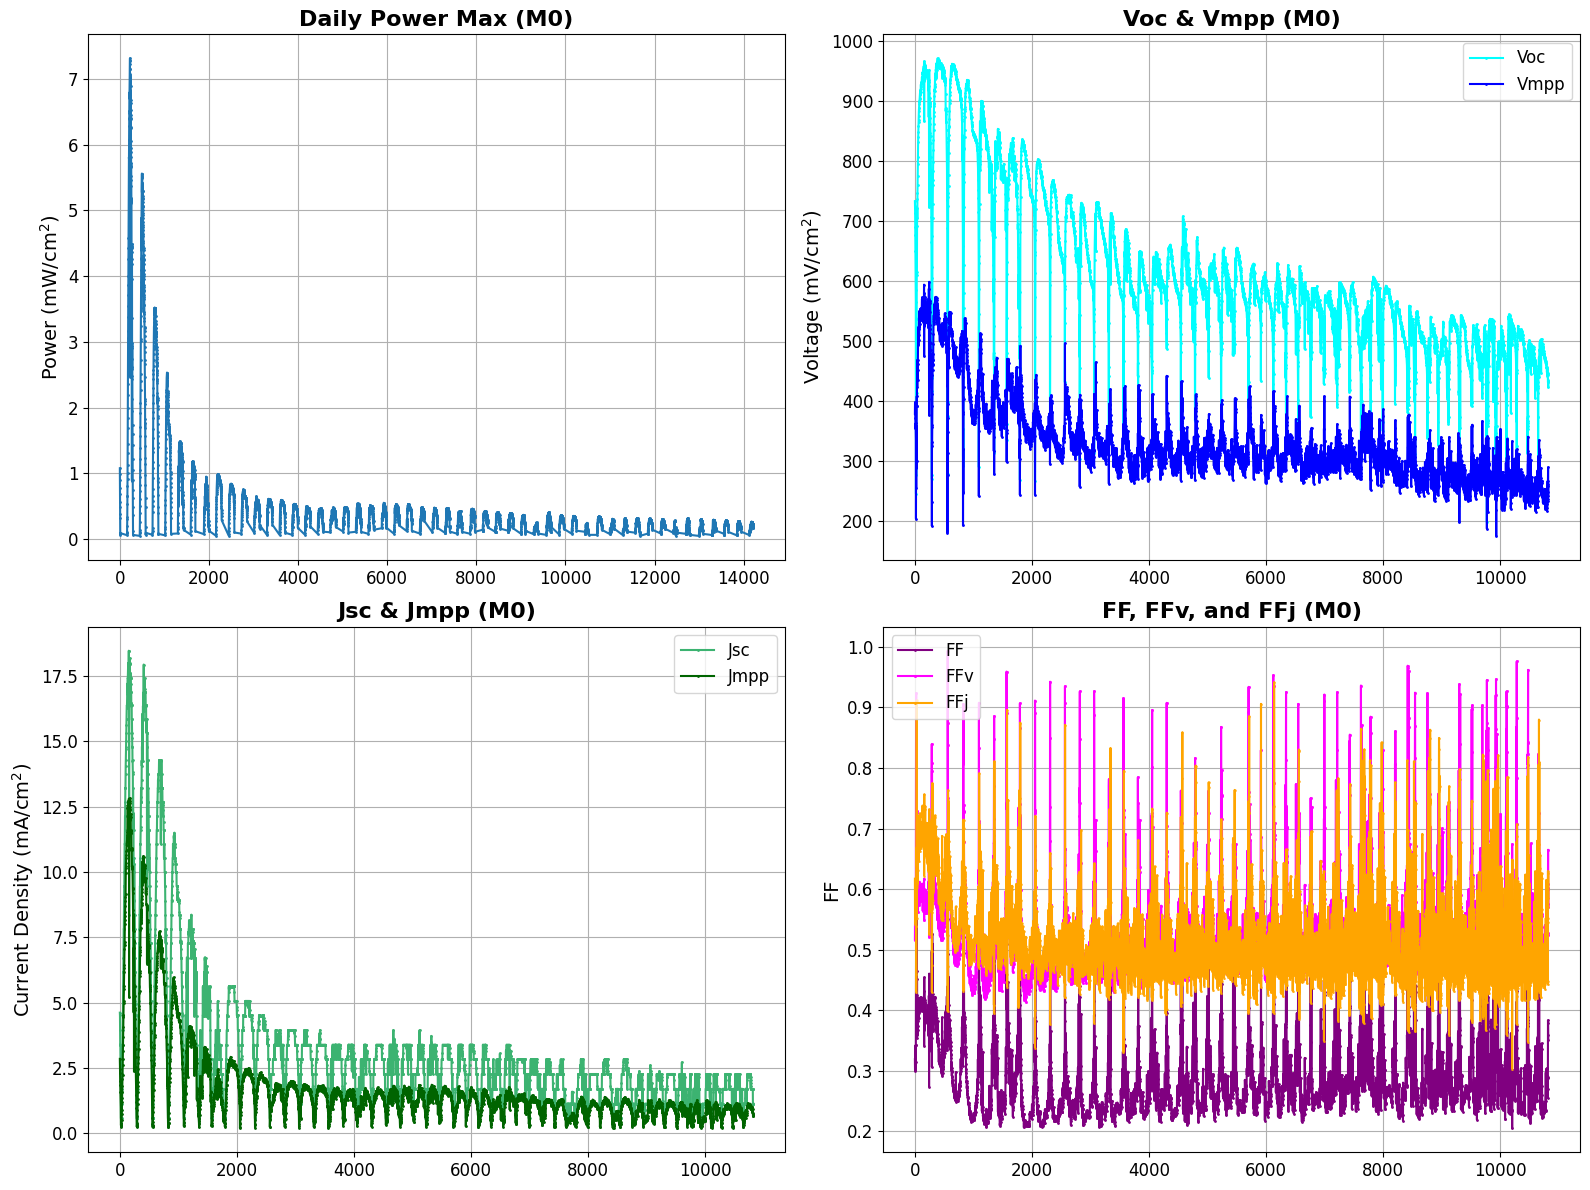

In [ ]:
plot_params(clean_params_df, 0, is_forward=True)

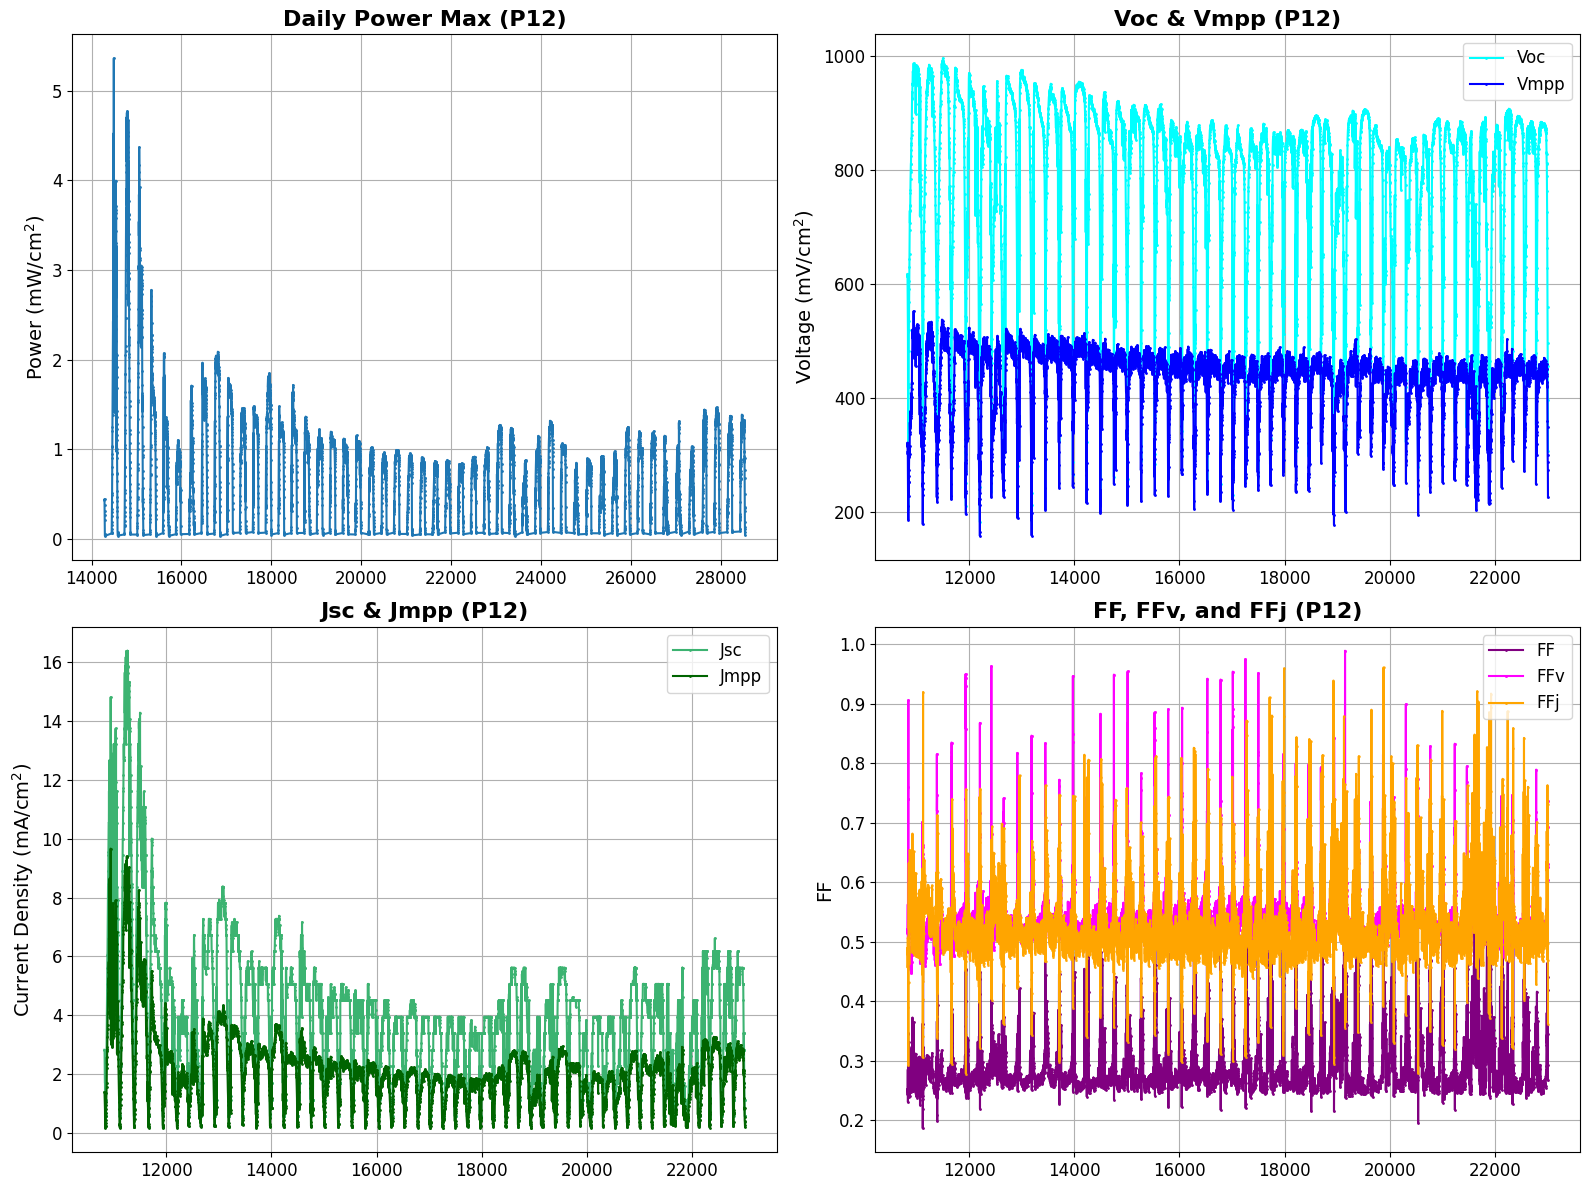

In [ ]:
plot_params(clean_params_df, 1, is_forward=True)

# **Method Validation: Regression vs. Simple Max**

In [ ]:
def compare_parameters_method(cell_id):
  df_all = plot_curves(jv, cell_id=cell_id, filter = True, plot_pow_den_curves=False, plot_parameters = False)

  clean_params_df_cell = clean_params_df.drop('is_forward', axis=1).loc[clean_params_df['cell_id'] == cell_id, :].groupby('id_curve').apply(lambda x:x.max(), include_groups=False)
  clean_params_df_cell_to_compare = clean_params_df_cell.loc[clean_params_df_cell.index.isin(df_all['id_curve'].values), :]
  clean_params_df_cell_to_compare.reset_index(inplace=True)
  df_all_time = df_all.index
  clean_params_df_cell_to_compare.insert(0, 'time', df_all_time)
  clean_params_df_cell_to_compare.set_index('time', inplace=True)

  # --- Style Configuration ---
  title_font = {'weight': 'bold', 'size': 16}
  label_font = {'weight': 'normal', 'size': 14}
  tick_size = 12

  # Create a figure with 4 rows and 2 columns
  # Increase width (32) to fit both columns well
  fig, axs = plt.subplots(4, 2, figsize=(32, 24))

  # LEFT COLUMN: COMPARISON (Original vs Regression)

  # --- Graph 1 (Left): Daily Power Max ---
  axs[0, 0].plot(df_all.index, df_all['DPM'], marker='o', label='DPM')
  axs[0, 0].plot(clean_params_df_cell_to_compare.index, clean_params_df_cell_to_compare['p_mpp'], marker='o', label='DPM_reg')
  axs[0, 0].grid(True)
  axs[0, 0].set_ylabel('Power (mW/cm$^2$)', fontdict=label_font)
  axs[0, 0].set_title(f'Daily Power Max ({cell_id})', fontdict=title_font)
  axs[0, 0].tick_params(axis='both', which='major', labelsize=tick_size)
  axs[0, 0].legend(loc='upper right', fontsize=12)

  # --- Graph 2 (Left): Voc & Vmpp ---
  axs[1, 0].plot(df_all.index, df_all['Voc'], marker='o', color='cyan', label='Voc')
  axs[1, 0].plot(df_all.index, df_all['Vmpp'], marker='o', color='blue', label='Vmpp')
  axs[1, 0].plot(clean_params_df_cell_to_compare.index, clean_params_df_cell_to_compare['voc'], marker='o', label='Voc_reg')
  axs[1, 0].plot(clean_params_df_cell_to_compare.index, clean_params_df_cell_to_compare['v_mpp'], marker='o', label='Vmpp_reg')
  axs[1, 0].grid(True)
  axs[1, 0].set_ylabel('Voltage (mV/cm$^2$)', fontdict=label_font)
  axs[1, 0].set_title(f'Voc & Vmpp ({cell_id})', fontdict=title_font)
  axs[1, 0].legend(loc='upper right', fontsize=12)
  axs[1, 0].tick_params(axis='both', which='major', labelsize=tick_size)

  # --- Graph 3 (Left): Jsc & Jmpp ---
  axs[2, 0].plot(df_all.index, df_all['Jsc'], marker='o', color='mediumseagreen', label='Jsc')
  axs[2, 0].plot(df_all.index, df_all['Jmpp'], marker='o', color='darkgreen', label='Jmpp')
  axs[2, 0].plot(clean_params_df_cell_to_compare.index, clean_params_df_cell_to_compare['jsc'], marker='o', label='Jsc_reg')
  axs[2, 0].plot(clean_params_df_cell_to_compare.index, clean_params_df_cell_to_compare['j_mpp'], marker='o', label='Jmpp_reg')
  axs[2, 0].grid(True)
  axs[2, 0].set_ylabel('Current Density (mA/cm$^2$)', fontdict=label_font)
  axs[2, 0].set_title(f'Jsc & Jmpp ({cell_id})', fontdict=title_font)
  axs[2, 0].legend(loc='upper right', fontsize=12)
  axs[2, 0].tick_params(axis='both', which='major', labelsize=tick_size)

  # --- Graph 4 (Left): FF, FFv, and FFj ---
  axs[3, 0].plot(df_all.index, df_all['FF'], label='FF', marker='o', color='purple')
  axs[3, 0].plot(df_all.index, df_all['FFv'], label='FFv', marker='s', color='magenta')
  axs[3, 0].plot(df_all.index, df_all['FFj'], label='FFj', marker='^', color='orange')
  axs[3, 0].plot(clean_params_df_cell_to_compare.index, clean_params_df_cell_to_compare['ff'], label='FF_reg', marker='o')
  axs[3, 0].plot(clean_params_df_cell_to_compare.index, clean_params_df_cell_to_compare['ff_v'], label='FFv_reg', marker='s')
  axs[3, 0].plot(clean_params_df_cell_to_compare.index, clean_params_df_cell_to_compare['ff_j'], label='FFj_reg', marker='^')
  axs[3, 0].grid(True)
  axs[3, 0].set_ylabel('FF', fontdict=label_font)
  axs[3, 0].set_title(f'FF, FFv, and FFj ({cell_id})', fontdict=title_font)
  axs[3, 0].legend(fontsize=12)
  axs[3, 0].tick_params(axis='both', which='major', labelsize=tick_size)

  # RIGHT COLUMN: RESIDUALS (Absolute Errors)

  # --- Graph 1 (Right): Residuals Daily Power Max ---
  res_dpm = (clean_params_df_cell_to_compare['p_mpp'] - df_all['DPM']).abs()

  axs[0, 1].vlines(x=df_all.index, ymin=0, ymax=res_dpm, color='red', alpha=0.5)
  axs[0, 1].plot(df_all.index, res_dpm, marker='o', linestyle='None', color='red', label='|DPM_reg - DPM|')
  axs[0, 1].grid(True, alpha=0.3)
  axs[0, 1].set_ylabel('Abs. Error (mW/cm$^2$)', fontdict=label_font)
  axs[0, 1].set_title(f'Residuals: Daily Power Max ({cell_id})', fontdict=title_font)
  axs[0, 1].tick_params(axis='both', which='major', labelsize=tick_size)
  axs[0, 1].legend(loc='upper right', fontsize=12)
  axs[0, 1].axhline(0, color='black', linewidth=1)

  # --- Graph 2 (Right): Residuals Voc & Vmpp ---
  res_voc = (clean_params_df_cell_to_compare['voc'] - df_all['Voc']).abs()
  res_vmpp = (clean_params_df_cell_to_compare['v_mpp'] - df_all['Vmpp']).abs()

  # Voc
  axs[1, 1].vlines(x=df_all.index, ymin=0, ymax=res_voc, color='cyan', alpha=0.6)
  axs[1, 1].plot(df_all.index, res_voc, marker='o', linestyle='None', color='cyan', label='|Voc_reg - Voc|')
  # Vmpp
  axs[1, 1].vlines(x=df_all.index, ymin=0, ymax=res_vmpp, color='blue', alpha=0.6)
  axs[1, 1].plot(df_all.index, res_vmpp, marker='o', linestyle='None', color='blue', label='|Vmpp_reg - Vmpp|')

  axs[1, 1].grid(True, alpha=0.3)
  axs[1, 1].set_ylabel('Abs. Error (mV)', fontdict=label_font)
  axs[1, 1].set_title(f'Residuals: Voc & Vmpp ({cell_id})', fontdict=title_font)
  axs[1, 1].legend(loc='upper right', fontsize=12)
  axs[1, 1].tick_params(axis='both', which='major', labelsize=tick_size)
  axs[1, 1].axhline(0, color='black', linewidth=1)

  # --- Graph 3 (Right): Residuals Jsc & Jmpp ---
  res_jsc = (clean_params_df_cell_to_compare['jsc'] - df_all['Jsc']).abs()
  res_jmpp = (clean_params_df_cell_to_compare['j_mpp'] - df_all['Jmpp']).abs()

  # Jsc
  axs[2, 1].vlines(x=df_all.index, ymin=0, ymax=res_jsc, color='mediumseagreen', alpha=0.6)
  axs[2, 1].plot(df_all.index, res_jsc, marker='o', linestyle='None', color='mediumseagreen', label='|Jsc_reg - Jsc|')
  # Jmpp
  axs[2, 1].vlines(x=df_all.index, ymin=0, ymax=res_jmpp, color='darkgreen', alpha=0.6)
  axs[2, 1].plot(df_all.index, res_jmpp, marker='o', linestyle='None', color='darkgreen', label='|Jmpp_reg - Jmpp|')

  axs[2, 1].grid(True, alpha=0.3)
  axs[2, 1].set_ylabel('Abs. Error (mA/cm$^2$)', fontdict=label_font)
  axs[2, 1].set_title(f'Residuals: Jsc & Jmpp ({cell_id})', fontdict=title_font)
  axs[2, 1].legend(loc='upper right', fontsize=12)
  axs[2, 1].tick_params(axis='both', which='major', labelsize=tick_size)
  axs[2, 1].axhline(0, color='black', linewidth=1)

  # --- Graph 4 (Right): Residuals FF, FFv, and FFj ---
  res_ff = (clean_params_df_cell_to_compare['ff'] - df_all['FF']).abs()
  res_ffv = (clean_params_df_cell_to_compare['ff_v'] - df_all['FFv']).abs()
  res_ffj = (clean_params_df_cell_to_compare['ff_j'] - df_all['FFj']).abs()

  # FF
  axs[3, 1].vlines(x=df_all.index, ymin=0, ymax=res_ff, color='purple', alpha=0.5)
  axs[3, 1].plot(df_all.index, res_ff, label='|FF_reg - FF|', marker='o', linestyle='None', color='purple')
  # FFv
  axs[3, 1].vlines(x=df_all.index, ymin=0, ymax=res_ffv, color='magenta', alpha=0.5)
  axs[3, 1].plot(df_all.index, res_ffv, label='|FFv_reg - FFv|', marker='s', linestyle='None', color='magenta')
  # FFj
  axs[3, 1].vlines(x=df_all.index, ymin=0, ymax=res_ffj, color='orange', alpha=0.5)
  axs[3, 1].plot(df_all.index, res_ffj, label='|FFj_reg - FFj|', marker='^', linestyle='None', color='orange')

  axs[3, 1].grid(True, alpha=0.3)
  axs[3, 1].set_ylabel('Abs. Error (FF Unit)', fontdict=label_font)
  axs[3, 1].set_title(f'Residuals: FF, FFv, and FFj ({cell_id})', fontdict=title_font)
  axs[3, 1].legend(fontsize=12)
  axs[3, 1].tick_params(axis='both', which='major', labelsize=tick_size)
  axs[3, 1].axhline(0, color='black', linewidth=1)

  plt.tight_layout()
  plt.show()
  return

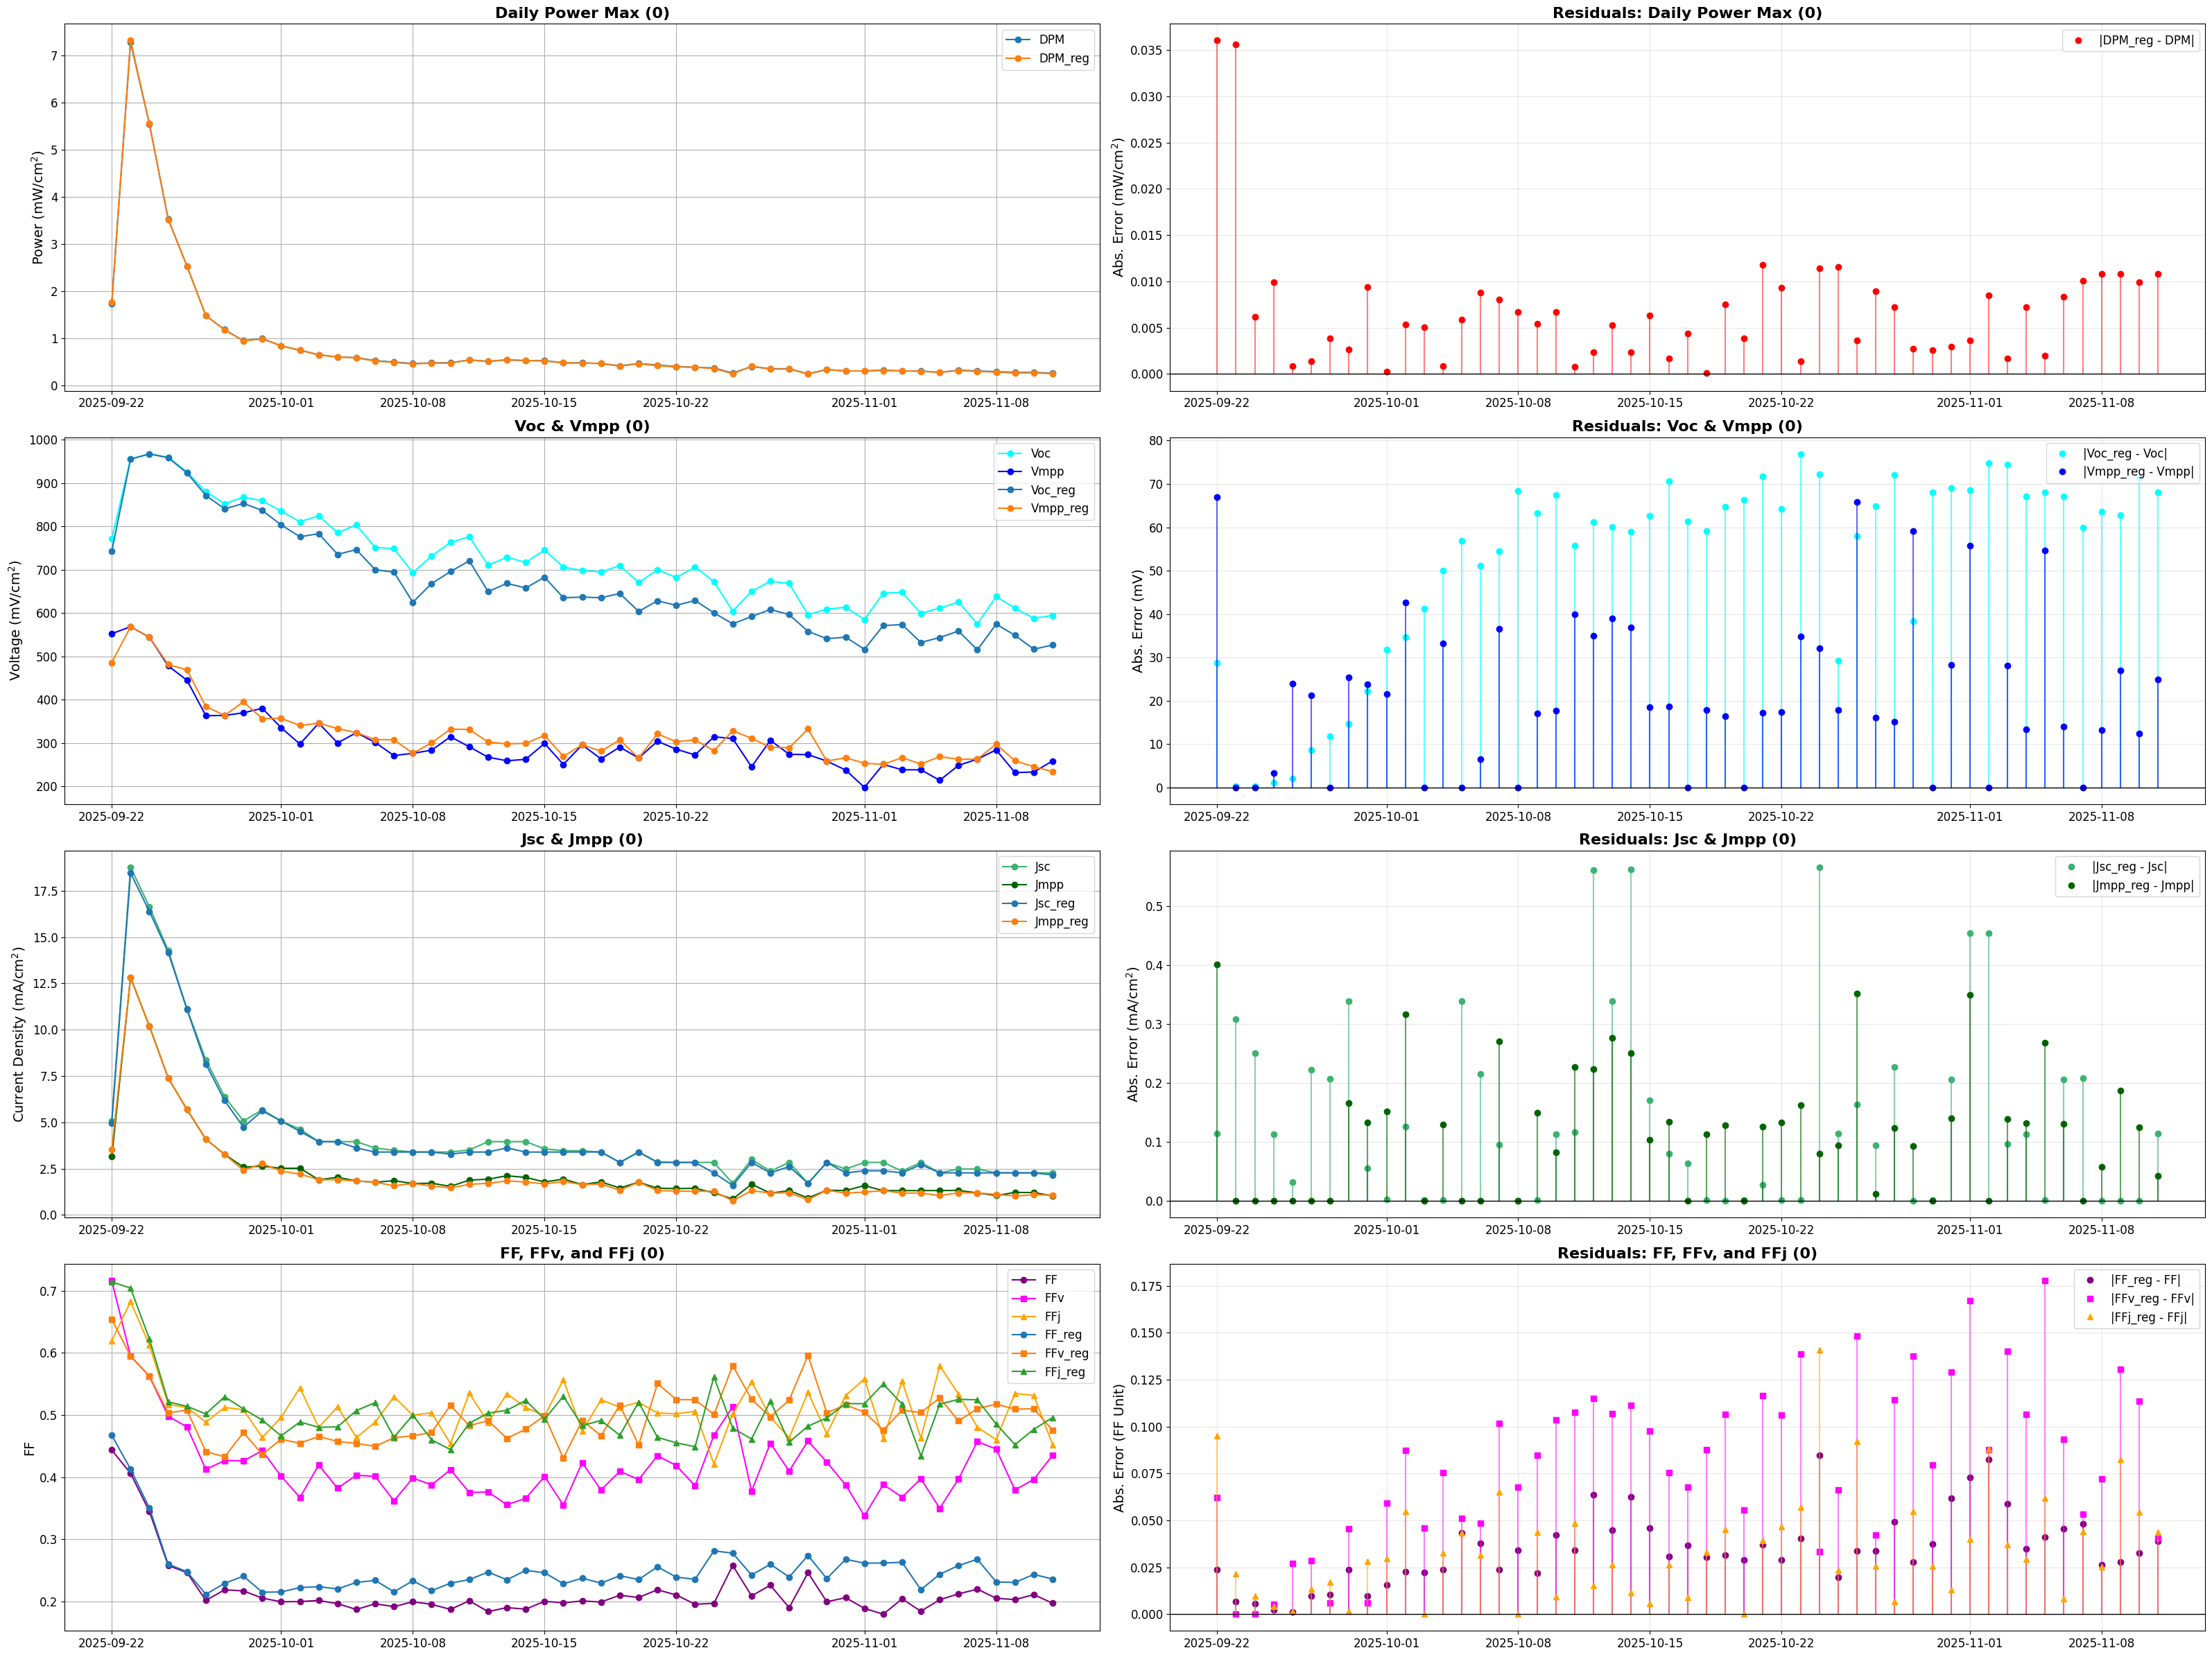

In [ ]:
compare_parameters_method(cell_id=0)

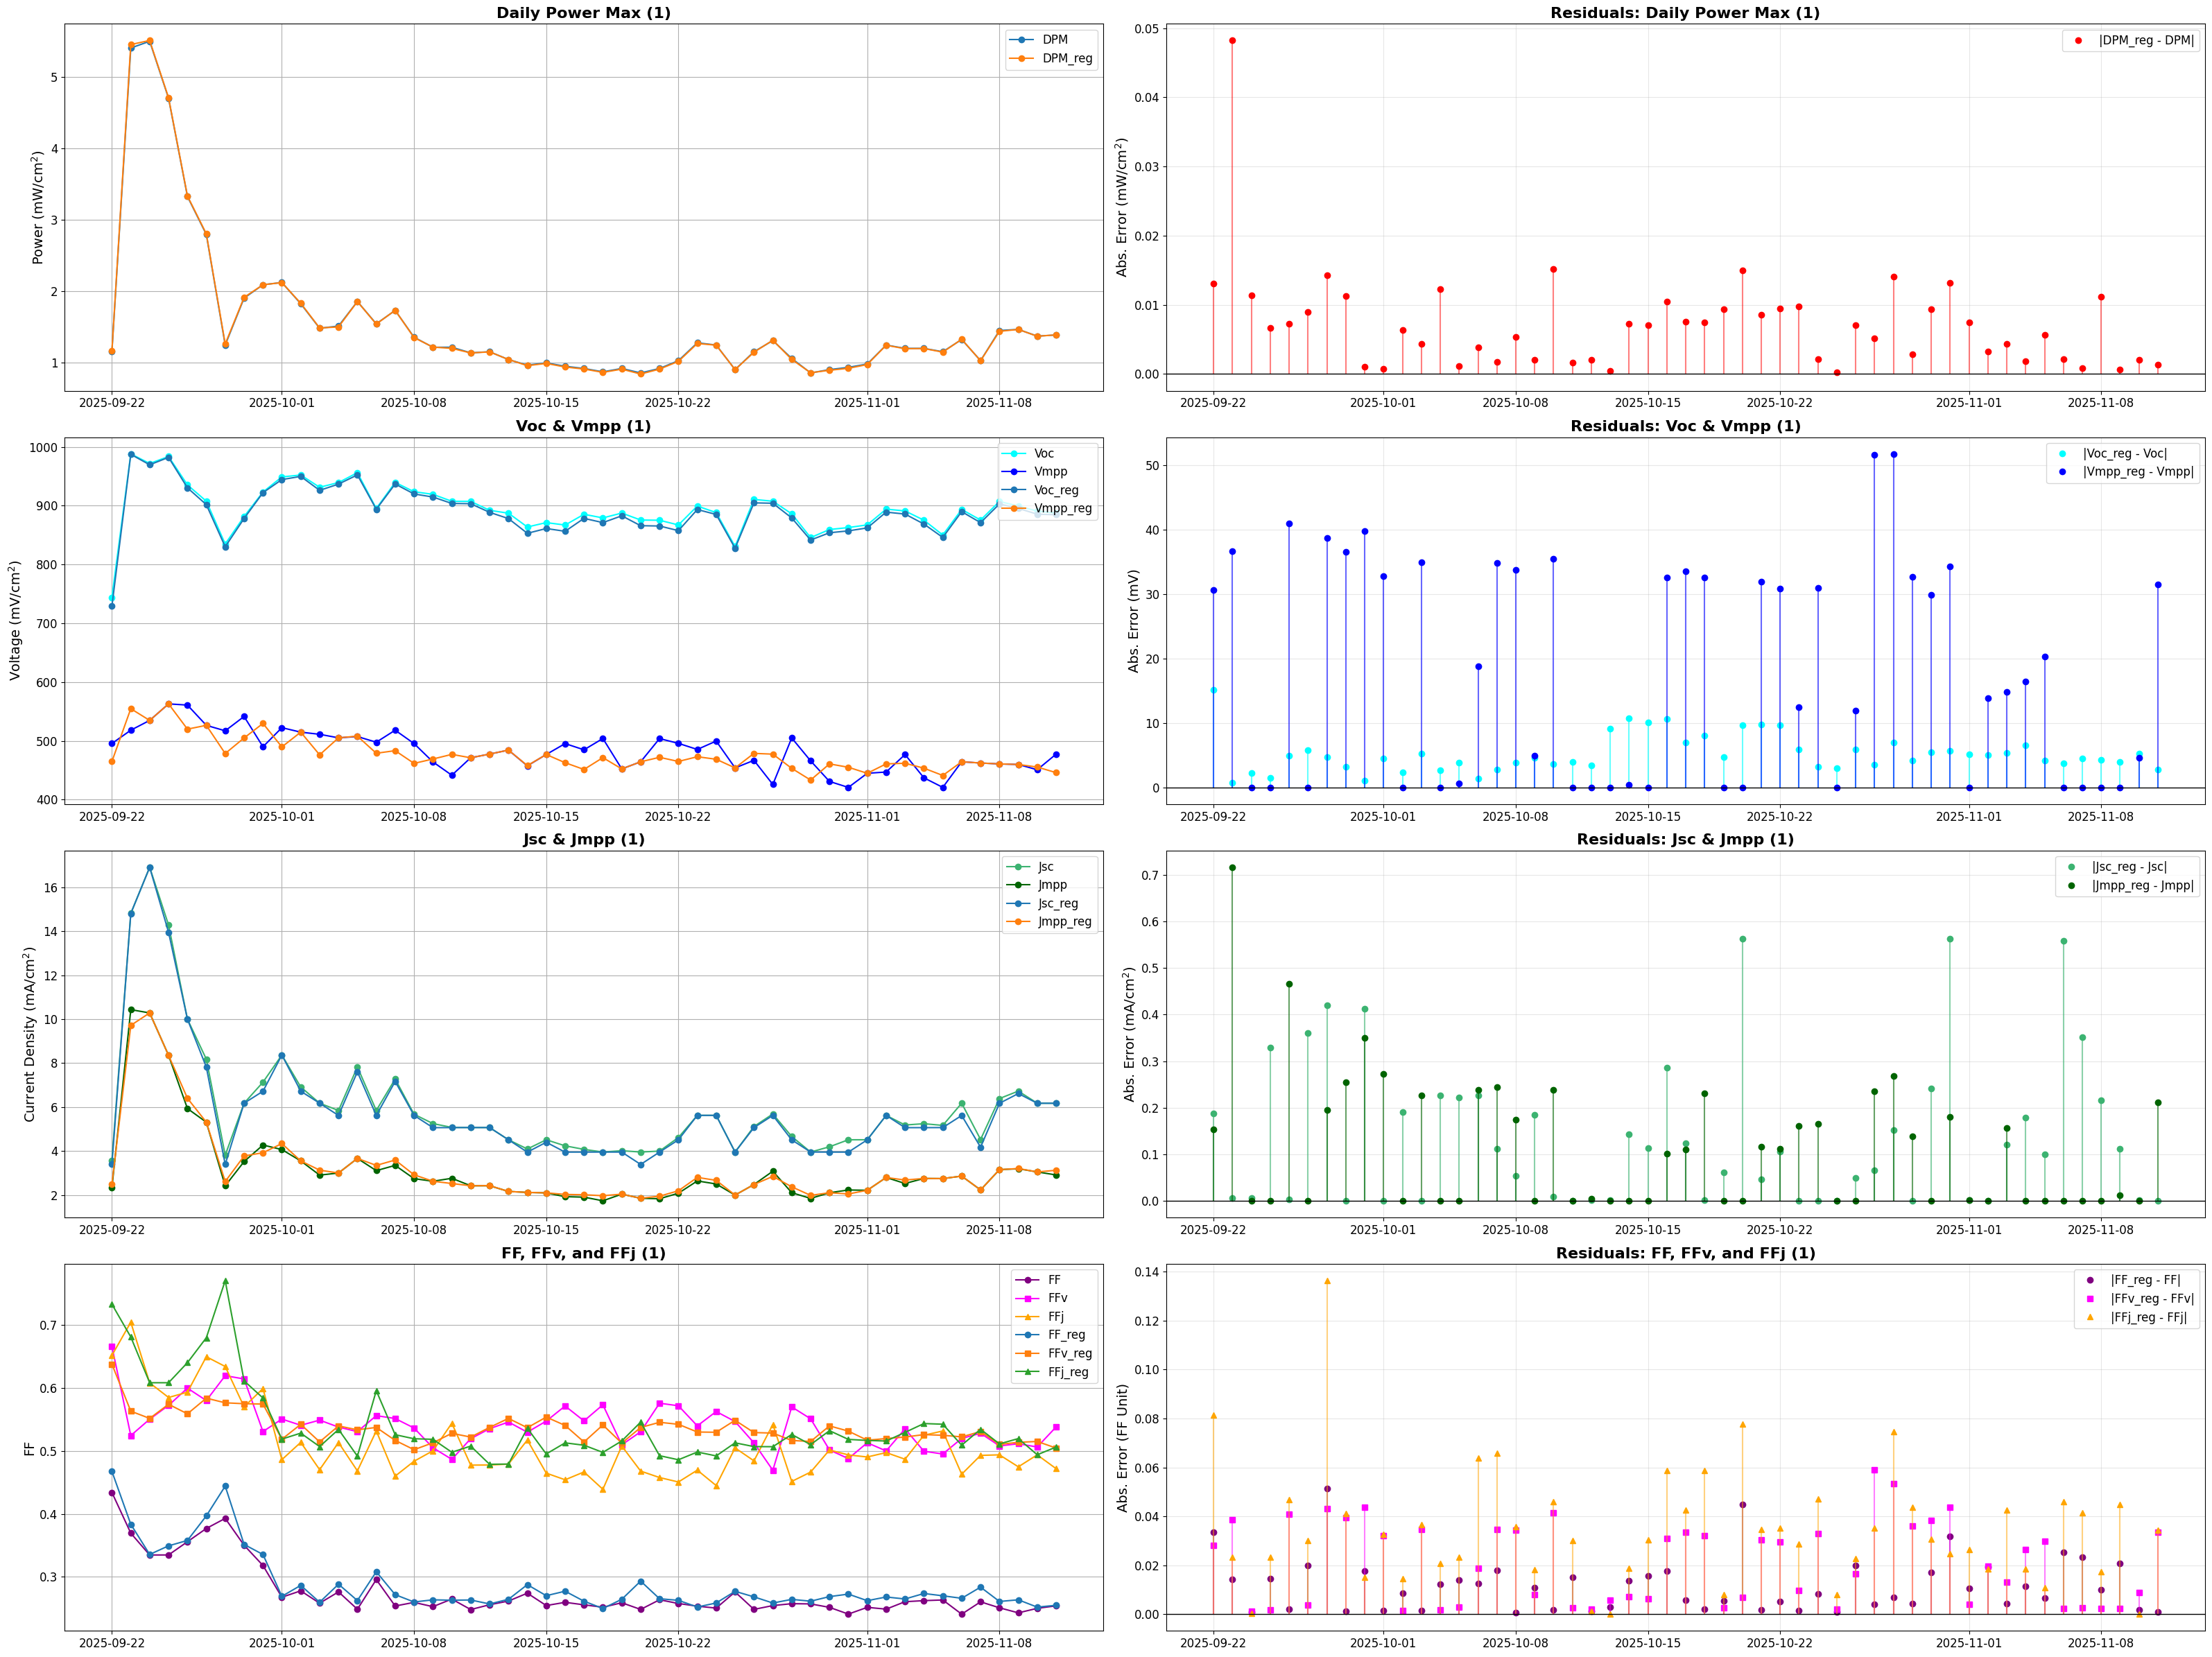

In [ ]:
compare_parameters_method(cell_id=1)

# **Curve Classification (K-Medoids clustering)**

In [ ]:
def curve_visualization(id_curve, only_forward=False, only_reverse=False):
  if jv.index.name == None:
    jv.set_index('time', inplace=True)

  fig, ax1 = plt.subplots(figsize=(16, 6))

  if only_forward == True:
    curve = jv.loc[(jv['id_curve'] == id_curve) & (jv['is_forward'] == 1), :]
  elif only_reverse == True:
    curve = jv.loc[(jv['id_curve'] == id_curve) & (jv['is_forward'] == 0), :]
  else:
    curve = jv[jv['id_curve'] == id_curve]

  # Extract cell_id and date from the current curve
  current_cell_id = curve['cell_id'].iloc[0]
  current_date = curve.index[0].date()

  ax1.plot(curve['voltage'], curve['power'], label='Power Density', color='tab:blue', marker='o', linewidth=2)
  ax1.set_xlabel('Voltage (mV)', fontsize=16)
  ax1.set_ylabel('Power Density (mW/cm$^{2}$)', color='tab:blue', fontsize=16)
  ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=14)
  ax1.tick_params(axis='x', labelsize=14)
  plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

  ax2 = ax1.twinx()

  ax2.plot(curve['voltage'], curve['current_density'], label='Current Density', color='tab:red', marker='x', linewidth=2)
  ax2.set_ylabel('Current Density (mA/cm$^2$)', color='tab:red', fontsize=16)
  ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=14)
  plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

  ax1.legend(loc='upper left')
  ax2.legend(loc='upper right')

  # Use the extracted current_date and current_cell_id for the title
  plt.title(f'Power and Current Density Curves for {current_date} (Curve ID: {id_curve}) (Cell ID: {current_cell_id})', fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()

  return (params_df.loc[params_df['id_curve'] == id_curve])

In [ ]:
def normalize_curve(jv, n_points=50):
    """
    Normalizes curves by capturing the complete hysteresis loop (100 points).
    Prevents extreme extrapolations towards negative values.
    """

    V = jv['voltage'].values
    J = jv['current_density'].values

    if len(V) < 10:
        return np.full(n_points * 2, np.nan)

    v_min, v_max = V.min(), V.max()
    j_min, j_max = J.min(), J.max()
    v_range = v_max - v_min
    j_range = j_max - j_min

    if v_range == 0 or j_range == 0:
        return np.full(n_points * 2, np.nan)

    idx_turn = np.argmax(np.abs(V - V[0]))

    if idx_turn < 5 or idx_turn > len(V) - 5:
        return np.full(n_points * 2, np.nan)

    V_rev, J_rev = V[:idx_turn+1], J[:idx_turn+1]
    V_fwd, J_fwd = V[idx_turn:], J[idx_turn:]

    def interpolate_sweep(v_sweep, j_sweep):
        v_norm = (v_sweep - v_min) / v_range
        j_norm = (j_sweep - j_min) / j_range

        sort_idx = np.argsort(v_norm)
        v_n_s, j_n_s = v_norm[sort_idx], j_norm[sort_idx]

        df_t = pd.DataFrame({'v': v_n_s, 'j': j_n_s}).groupby('v', as_index=False).mean()

        if len(df_t) < 2: return np.full(n_points, np.nan)

        f = interp1d(df_t['v'], df_t['j'], kind='linear', bounds_error=False,
                     fill_value=(df_t['j'].iloc[0], df_t['j'].iloc[-1]))
        return f(np.linspace(0, 1, n_points))

    try:
        return np.concatenate([interpolate_sweep(V_rev, J_rev), interpolate_sweep(V_fwd, J_fwd)])
    except:
        return np.full(n_points * 2, np.nan)

def plot_confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    if x.size < 2 or y.size < 2: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

def get_label_curves_kmedoids(n_points=50, n_clusters=4):
    """
    Performs clustering on JV curves using PCA followed by K-Medoids.
    Returns the labeled datasets.
    """
    global jv, clean_params_df

    # --- 1. PROCESSING AND CLEANING ---
    jv_valid = jv[jv['is_curve_valid'] == 1].copy()
    if 'label_curve' in jv_valid.columns: jv_valid.drop('label_curve', axis=1, inplace=True)
    if 'label_curve' in clean_params_df.columns: clean_params_df.drop('label_curve', axis=1, inplace=True)

    curves_normalized = jv_valid.groupby(['cell_id', 'curve']).apply(
        lambda x: normalize_curve(x, n_points), include_groups=False
    )
    valid_mask = ~curves_normalized.apply(lambda x: np.isnan(x).any())
    curves_normalized = curves_normalized[valid_mask]
    X = np.stack(curves_normalized.values)

    # --- 2. PIPELINE: PCA -> KMEDOIDS ---
    pca_full = PCA().fit(X)
    pca = PCA(n_components=2)
    X_pca_vals = pca.fit_transform(X)

    # =========================================================
    # FIGURE 1: Cumulative Variance and Physical Loadings
    # =========================================================
    fig_pca, (ax_var, ax_load) = plt.subplots(1, 2, figsize=(16, 6))

    # Subplot 1.1: Cumulative Variance
    max_comps = min(10, X.shape[1] - 1)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)[:max_comps + 1]
    n_components_x = range(1, len(cum_var) + 1)

    ax_var.plot(n_components_x, cum_var, marker='o', lw=3, ms=8, color='teal')
    ax_var.axhline(y=0.90, color='r', linestyle='--', lw=2, label='90% Explained Variance')
    ax_var.set_xticks(range(1, max_comps + 2))
    ax_var.set_xlim(0.5, max_comps + 1.5)

    ax_var.set_xlabel('Number of Components', fontsize=16)
    ax_var.set_ylabel('Cumulative Explained Variance', fontsize=16)
    ax_var.set_title('PCA: Cumulative Explained Variance', fontsize=18, fontweight='bold')
    ax_var.tick_params(axis='both', labelsize=14)
    ax_var.grid(True, linestyle='--', alpha=0.5)
    ax_var.legend(fontsize=14)

    # Subplot 1.2: PCA Loadings
    v_norm = np.linspace(0, 1, n_points)
    pc1_rev, pc1_fwd = pca.components_[0, :n_points], pca.components_[0, n_points:]
    pc2_rev, pc2_fwd = pca.components_[1, :n_points], pca.components_[1, n_points:]

    ax_load.plot(v_norm, pc1_rev, '-', lw=3, color='tab:blue', label='PC1 (Reverse)')
    ax_load.plot(v_norm, pc1_fwd, '--', lw=3, color='tab:blue', alpha=0.6, label='PC1 (Forward)')
    ax_load.plot(v_norm, pc2_rev, '-', lw=3, color='tab:orange', label='PC2 (Reverse)')
    ax_load.plot(v_norm, pc2_fwd, '--', lw=3, color='tab:orange', alpha=0.6, label='PC2 (Forward)')

    ax_load.axhline(0, color='black', lw=1, linestyle='--')
    ax_load.set_xlabel('Normalized Voltage', fontsize=16)
    ax_load.set_ylabel('Loading Weight', fontsize=16)
    ax_load.set_title('PCA Loadings: Physical Significance', fontsize=18, fontweight='bold')
    ax_load.tick_params(axis='both', labelsize=14)
    ax_load.grid(True, linestyle='--', alpha=0.3)
    ax_load.legend(fontsize=12, loc='best')

    plt.tight_layout()
    plt.show()

    # KMedoids on Principal Components
    kmeans = KMedoids(n_clusters=n_clusters, random_state=42, method='pam')
    labels = kmeans.fit_predict(X_pca_vals)

    # Reorder clusters based on Pseudo-FF
    centers_orig = pca.inverse_transform(kmeans.cluster_centers_)
    pseudo_ff = [np.max(v_norm * center[n_points:]) for center in centers_orig]
    sorted_indices = np.argsort(pseudo_ff)[::-1]

    label_mapping = {old_label: new_label for new_label, old_label in enumerate(sorted_indices)}
    labels = np.array([label_mapping[l] for l in labels])
    kmeans.cluster_centers_ = kmeans.cluster_centers_[sorted_indices]

    # --- 3. METRIC CALCULATION ---
    inertia = []
    silhouette_avg_list = []
    cluster_range = range(2, n_clusters + 5)
    for k in cluster_range:
        km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
        lbls_temp = km_temp.fit_predict(X_pca_vals)
        inertia.append(km_temp.inertia_)
        silhouette_avg_list.append(silhouette_score(X_pca_vals, lbls_temp))

    # =========================================================
    # FIGURE 2: Curve Classification and Cluster Metrics
    # =========================================================
    fig, (ax_cl, ax_metrics) = plt.subplots(1, 2, figsize=(20, 8))
    colors_arr = plt.cm.viridis(np.linspace(0, 1, n_clusters))
    custom_cmap = ListedColormap(colors_arr)

    # SUBPLOT 2.1: Curve Classification
    for i in range(n_clusters):
        mask = labels == i
        X_cluster = X[mask]

        mean_curve = X_cluster.mean(axis=0)
        std_curve = X_cluster.std(axis=0)

        # Lines and Areas
        line = ax_cl.plot(v_norm, mean_curve[:n_points], label=f'Type {i}', color=colors_arr[i], linewidth=3.5)
        ax_cl.fill_between(v_norm, mean_curve[:n_points] - std_curve[:n_points],
                           mean_curve[:n_points] + std_curve[:n_points], color=colors_arr[i], alpha=0.25)

        ax_cl.plot(v_norm, mean_curve[n_points:], linestyle='--', color=line[0].get_color(), linewidth=2.5)
        ax_cl.fill_between(v_norm, mean_curve[n_points:] - std_curve[n_points:],
                           mean_curve[n_points:] + std_curve[n_points:], color=colors_arr[i], alpha=0.15)

    ax_cl.set_title("Classification of Hysteresis Loops", fontsize=20, fontweight='bold', pad=20)
    ax_cl.set_xlabel('Normalized Voltage', fontsize=16, labelpad=12)
    ax_cl.set_ylabel("Normalized Current", fontsize=16, labelpad=12)
    ax_cl.tick_params(axis='both', labelsize=14)
    ax_cl.grid(True, linestyle='--', alpha=0.5)

    style_elements = [
        Line2D([0], [0], color='gray', lw=3, label='Reverse Scan'),
        Line2D([0], [0], color='gray', lw=3, linestyle='--', label='Forward Scan'),
        mpatches.Patch(color='gray', alpha=0.3, label='± 1 Std Dev Area')
    ]
    handles, labels_types = ax_cl.get_legend_handles_labels()
    ax_cl.legend(handles=style_elements + handles, loc='best', fontsize=12, ncol=2)

    # SUBPLOT 2.2: Elbow + Silhouette
    color_wcss = 'tab:blue'
    ax_metrics.set_xlabel('Number of Clusters (k)', fontsize=16)
    ax_metrics.set_ylabel('Inertia (WCSS)', color=color_wcss, fontsize=16)
    lns1 = ax_metrics.plot(cluster_range, inertia, marker='o', color=color_wcss, lw=3, ms=10, label='Inertia')
    ax_metrics.tick_params(axis='y', labelcolor=color_wcss, labelsize=14)
    ax_metrics.tick_params(axis='x', labelsize=14)

    ax_sil = ax_metrics.twinx()
    color_sil = 'tab:red'
    ax_sil.set_ylabel('Silhouette Score', color=color_sil, fontsize=16)
    lns2 = ax_sil.plot(cluster_range, silhouette_avg_list, marker='s', color=color_sil, lw=3, ms=10, label='Silhouette')
    ax_sil.tick_params(axis='y', labelcolor=color_sil, labelsize=14)
    ax_sil.set_ylim(0, 1)

    lns = lns1 + lns2
    labs = [l.get_label() for l in lns]
    ax_metrics.legend(lns, labs, loc='upper right', fontsize=14)
    ax_metrics.set_title('Optimal Clusters Validation', fontsize=20, fontweight='bold', pad=20)
    ax_metrics.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =========================================================
    # FIGURE 3: PCA Scatter Plot
    # =========================================================
    plt.figure(figsize=(10, 7))
    ax_pca = plt.gca()

    # 1. Background boundaries
    h = .02
    x_min, x_max = X_pca_vals[:, 0].min() - 0.5, X_pca_vals[:, 0].max() + 0.5
    y_min, y_max = X_pca_vals[:, 1].min() - 0.5, X_pca_vals[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.15, cmap=custom_cmap)

    scatter_handles = []
    for i in range(n_clusters):
        mask = labels == i
        scatter = plt.scatter(X_pca_vals[mask, 0], X_pca_vals[mask, 1],
                              color=colors_arr[i], alpha=0.8, s=90, edgecolors='w', linewidth=0.8, label=f'Type {i}')
        scatter_handles.append(scatter)

        plot_confidence_ellipse(X_pca_vals[mask, 0], X_pca_vals[mask, 1], ax_pca,
                                n_std=1.0, edgecolor='#E63946', facecolor='none',
                                linestyle='--', linewidth=2.5, alpha=1.0, zorder=10)

    plt.title(f"PCA: Cluster Spatial Distribution and Boundaries (k={n_clusters})", fontsize=20, fontweight='bold', pad=20)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)", fontsize=16, labelpad=10)
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)", fontsize=16, labelpad=10)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    ellipse_legend = Line2D([0], [0], color='#333333', lw=2.5, linestyle='--', label='1 σ Confidence Ellipse')
    plt.legend(handles=scatter_handles + [ellipse_legend], fontsize=12, loc='best', title="Clusters", title_fontsize=14, framealpha=0.9)

    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    # --- 8. LABEL RECONSTRUCTION AND RETURN ---
    labels_bridge = curves_normalized.index.to_frame(index=False)
    labels_bridge['label_curve'] = labels

    # A) Label jv_valid
    jv_valid_labeled = jv_valid.merge(labels_bridge, on=['cell_id', 'curve'], how='inner')

    # B) Label clean_params_df
    id_to_label = jv_valid_labeled[['id_curve', 'label_curve']].drop_duplicates()
    clean_params_df_labeled = clean_params_df.merge(id_to_label, on='id_curve', how='left')

    n_nans = clean_params_df_labeled['label_curve'].isna().sum()
    print(f"Process finished. Rows without labels in params: {n_nans}")

    return jv_valid_labeled, clean_params_df_labeled

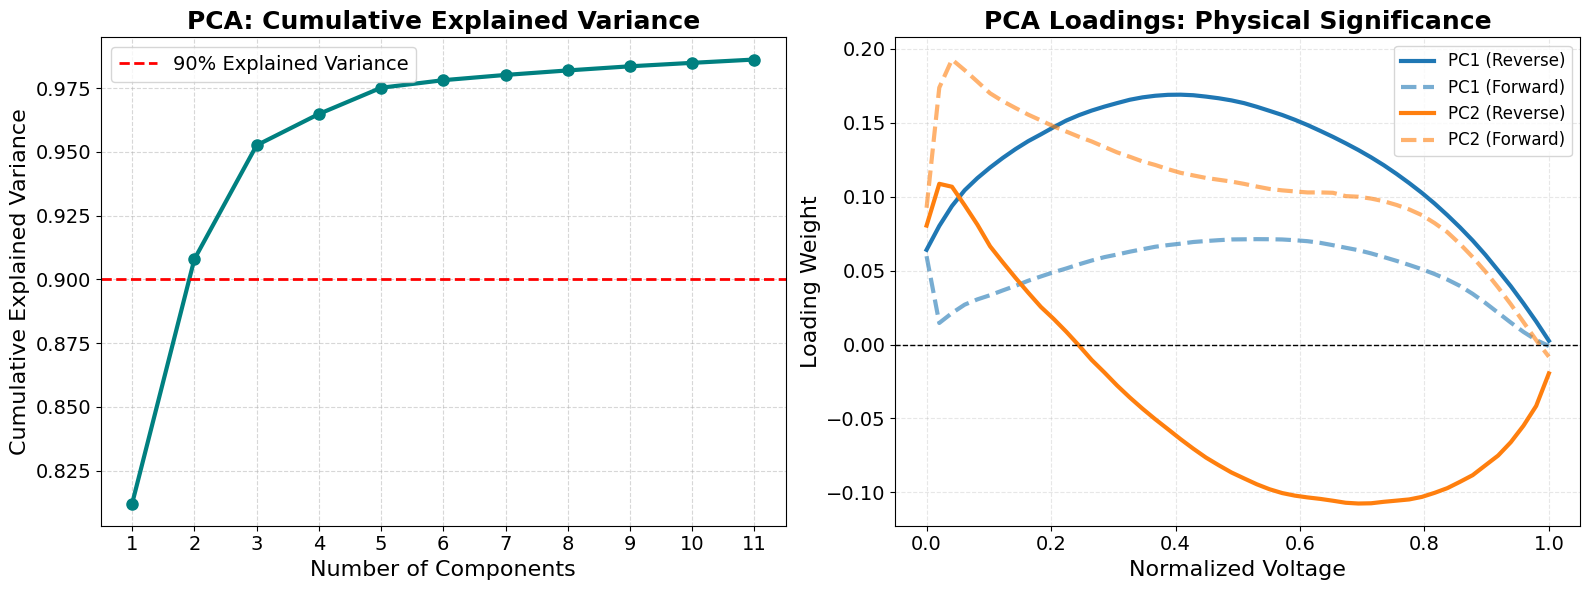

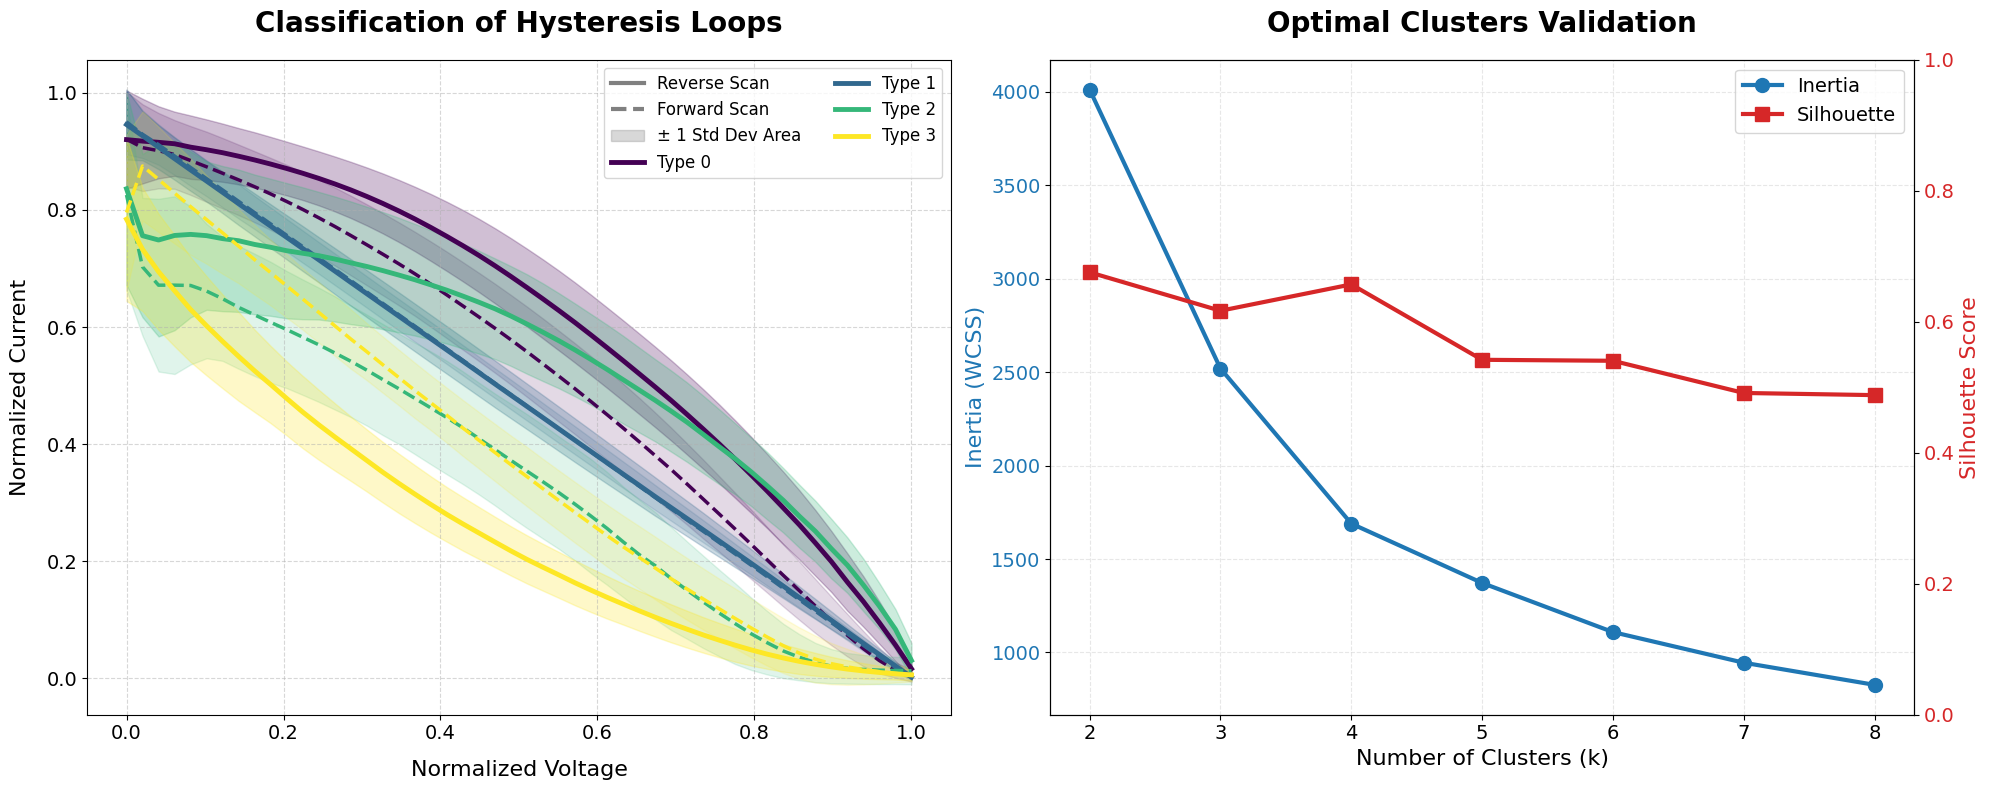

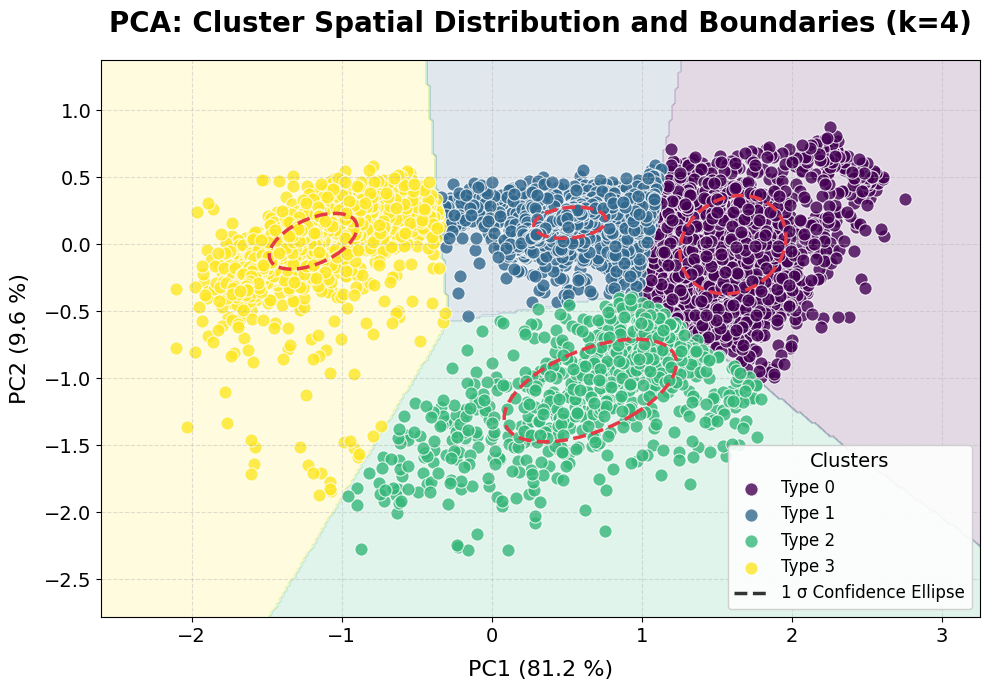

Proceso finalizado. Filas sin etiqueta en params: 0


In [ ]:
jv_valid_labeled, clean_params_df_labeled = get_label_curves_kmedoids(n_clusters=4)

In [ ]:
jv_valid_labeled

,time,cell_id,id_curve,integer4725,voltage,power,curve,current_density,is_forward,v_span,is_curve_valid,label_curve
0,2025-09-22 18:36:33.331315,0,1,1250,720.87,0.187500,1,0.260102,0,743.41,1,0
1,2025-09-22 18:36:33.512825,0,1,1255,737.40,0.203125,1,0.275461,0,743.41,1,0
2,2025-09-22 18:36:33.658098,0,1,1260,745.80,0.203125,1,0.272359,0,743.41,1,0
3,2025-09-22 18:36:33.803219,0,1,1265,751.54,0.218750,1,0.291069,0,743.41,1,0
4,2025-09-22 18:36:33.948513,0,1,1270,756.07,0.218750,1,0.289325,0,743.41,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1955505,2025-11-11 17:25:47.724239,1,28535,1270,295.52,0.031250,14249,0.105746,1,407.45,1,3
1955506,2025-11-11 17:25:47.869611,1,28535,1265,306.86,0.046875,14249,0.152757,1,407.45,1,3
1955507,2025-11-11 17:25:48.014456,1,28535,1260,315.39,0.046875,14249,0.148626,1,407.45,1,3
1955508,2025-11-11 17:25:48.159529,1,28535,1255,323.39,0.031250,14249,0.096633,1,407.45,1,3


In [ ]:
clean_params_df_labeled

,cell_id,id_curve,is_forward,voc,jsc,p_mpp,v_mpp,j_mpp,ff,ff_v,ff_j,label_curve
0,0,1,0,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341,0
1,0,1,1,732.548,4.618782,1.076887,378.26,2.850222,0.318644,0.516362,0.617094,0
2,0,2,0,750.842,4.511007,1.644996,521.61,3.085399,0.475155,0.694700,0.683971,0
3,0,2,1,723.854,4.511007,0.984776,397.44,2.476789,0.301464,0.549061,0.549055,0
4,0,3,0,750.920,3.951409,1.511582,513.60,2.859716,0.494997,0.683961,0.723721,0
...,...,...,...,...,...,...,...,...,...,...,...,...
22723,1,28533,1,457.388,0.569840,0.107627,288.74,0.378801,0.419644,0.631280,0.664750,2
22724,1,28534,0,504.616,0.570047,0.123325,381.40,0.327740,0.434548,0.755822,0.574934,2
22725,1,28534,1,396.376,0.570047,0.081403,274.73,0.284370,0.345758,0.693105,0.498853,2
22726,1,28535,0,423.096,0.570255,0.082095,332.33,0.235083,0.323804,0.785472,0.412241,3


In [ ]:
for k in jv_valid_labeled[jv_valid_labeled['label_curve']==8]['id_curve'].unique()[:10]:
  curve_visualization(k)

# **Data Integration and Restructuring**

In [ ]:
jv_valid_labeled

,time,cell_id,id_curve,integer4725,voltage,power,curve,current_density,is_forward,v_span,is_curve_valid,label_curve
0,2025-09-22 18:36:33.331315,0,1,1250,720.87,0.187500,1,0.260102,0,743.41,1,0
1,2025-09-22 18:36:33.512825,0,1,1255,737.40,0.203125,1,0.275461,0,743.41,1,0
2,2025-09-22 18:36:33.658098,0,1,1260,745.80,0.203125,1,0.272359,0,743.41,1,0
3,2025-09-22 18:36:33.803219,0,1,1265,751.54,0.218750,1,0.291069,0,743.41,1,0
4,2025-09-22 18:36:33.948513,0,1,1270,756.07,0.218750,1,0.289325,0,743.41,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1955505,2025-11-11 17:25:47.724239,1,28535,1270,295.52,0.031250,14249,0.105746,1,407.45,1,3
1955506,2025-11-11 17:25:47.869611,1,28535,1265,306.86,0.046875,14249,0.152757,1,407.45,1,3
1955507,2025-11-11 17:25:48.014456,1,28535,1260,315.39,0.046875,14249,0.148626,1,407.45,1,3
1955508,2025-11-11 17:25:48.159529,1,28535,1255,323.39,0.031250,14249,0.096633,1,407.45,1,3


In [ ]:
clean_params_df_labeled

,cell_id,id_curve,is_forward,voc,jsc,p_mpp,v_mpp,j_mpp,ff,ff_v,ff_j,label_curve
0,0,1,0,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341,0
1,0,1,1,732.548,4.618782,1.076887,378.26,2.850222,0.318644,0.516362,0.617094,0
2,0,2,0,750.842,4.511007,1.644996,521.61,3.085399,0.475155,0.694700,0.683971,0
3,0,2,1,723.854,4.511007,0.984776,397.44,2.476789,0.301464,0.549061,0.549055,0
4,0,3,0,750.920,3.951409,1.511582,513.60,2.859716,0.494997,0.683961,0.723721,0
...,...,...,...,...,...,...,...,...,...,...,...,...
22723,1,28533,1,457.388,0.569840,0.107627,288.74,0.378801,0.419644,0.631280,0.664750,2
22724,1,28534,0,504.616,0.570047,0.123325,381.40,0.327740,0.434548,0.755822,0.574934,2
22725,1,28534,1,396.376,0.570047,0.081403,274.73,0.284370,0.345758,0.693105,0.498853,2
22726,1,28535,0,423.096,0.570255,0.082095,332.33,0.235083,0.323804,0.785472,0.412241,3


In [ ]:
def merge_jv_data(jv_valid_labeled, clean_params_df_labeled):
    print("--- Starting IV Curves merger (merge_jv_data) ---")

    # Backup copies to avoid altering global variables
    jv = jv_valid_labeled.copy()
    jv_params = clean_params_df_labeled.copy()

    # Removal of residual index column if it exists
    if 'index' in jv.columns:
        jv.drop('index', axis=1, inplace=True)

    print(f"Initial rows in JV: {len(jv)}")

    params_idx = jv_params.loc[:, ['id_curve','cell_id','is_forward']]

    # Inner join filtering
    jv_filtered = jv.merge(params_idx, on=['id_curve', 'cell_id', 'is_forward'], how='inner')
    print(f"Rows in JV after filtering by existing parameters: {len(jv_filtered)}")

    # Extraction of the timestamp of the last point of the curve
    print("Grouping to obtain timestamps...")
    params_time = jv_filtered.groupby(['id_curve','cell_id','is_forward']).progress_apply(lambda x:x.iloc[-1], include_groups=False)['time']

    # Preparation of params
    jv_params.set_index(['id_curve','cell_id','is_forward'], inplace=True)
    jv_params = jv_params.join(params_time)

    jv_params.reset_index(inplace=True)
    jv_params.set_index('time', inplace=True)

    # Preparation of jv and merge with params
    jv.reset_index(inplace=True)
    jv.set_index('time', inplace=True)

    cols_to_add = jv_params.drop(['id_curve', 'cell_id', 'is_forward', 'label_curve'], axis=1).columns
    cols_to_drop_from_jv = [c for c in cols_to_add if c in jv.columns]

    if cols_to_drop_from_jv:
        jv.drop(columns=cols_to_drop_from_jv, inplace=True)

    # Join and backfill
    print("Joining parameters to raw data and applying bfill...")
    jv = jv.join(jv_params.drop(['id_curve', 'cell_id', 'is_forward', 'label_curve'], axis=1)).bfill()

    if 'index' in jv.columns:
        jv.drop('index', axis=1, inplace=True)

    jv = jv[['id_curve', 'cell_id', 'curve', 'is_forward', 'integer4725', 'voltage',
             'power', 'current_density', 'v_span', 'is_curve_valid',
             'voc', 'jsc', 'p_mpp', 'v_mpp', 'j_mpp', 'ff', 'ff_v',
             'ff_j', 'label_curve']]
    print(f"--- Merger finished. Final shape: {jv.shape} ---")

    return jv, jv_params

In [ ]:
jv, jv_params = merge_jv_data(jv_valid_labeled, clean_params_df_labeled)

--- Starting IV Curves merger (merge_jv_data) ---
Initial rows in JV: 1955510
Rows in JV after filtering by existing parameters: 1931880
Grouping to obtain timestamps...


100%|██████████| 22728/22728 [00:04<00:00, 4889.70it/s]


Joining parameters to raw data and applying bfill...
--- Merger finished. Final shape: (1955510, 19) ---


In [ ]:
jv

,id_curve,cell_id,curve,is_forward,integer4725,voltage,power,current_density,v_span,is_curve_valid,voc,jsc,p_mpp,v_mpp,j_mpp,ff,ff_v,ff_j,label_curve
time,,,,,,,,,,,,,,,,,,,
2025-09-22 18:36:33.331315,1,0,1,0,1250,720.87,0.187500,0.260102,743.41,1,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341,0
2025-09-22 18:36:33.512825,1,0,1,0,1255,737.40,0.203125,0.275461,743.41,1,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341,0
2025-09-22 18:36:33.658098,1,0,1,0,1260,745.80,0.203125,0.272359,743.41,1,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341,0
2025-09-22 18:36:33.803219,1,0,1,0,1265,751.54,0.218750,0.291069,743.41,1,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341,0
2025-09-22 18:36:33.948513,1,0,1,0,1270,756.07,0.218750,0.289325,743.41,1,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-11 17:25:47.724239,28535,1,14249,1,1270,295.52,0.031250,0.105746,407.45,1,307.442,0.570255,0.047567,226.46,0.206990,0.267368,0.736594,0.362978,3
2025-11-11 17:25:47.869611,28535,1,14249,1,1265,306.86,0.046875,0.152757,407.45,1,307.442,0.570255,0.047567,226.46,0.206990,0.267368,0.736594,0.362978,3
2025-11-11 17:25:48.014456,28535,1,14249,1,1260,315.39,0.046875,0.148626,407.45,1,307.442,0.570255,0.047567,226.46,0.206990,0.267368,0.736594,0.362978,3


In [ ]:
jv_params

,id_curve,cell_id,is_forward,voc,jsc,p_mpp,v_mpp,j_mpp,ff,ff_v,ff_j,label_curve
time,,,,,,,,,,,,
2025-09-22 18:36:45.555318,1,0,0,742.336,4.955645,1.770396,485.52,3.540019,0.467210,0.654043,0.714341,0
2025-09-22 18:36:57.887850,1,0,1,732.548,4.618782,1.076887,378.26,2.850222,0.318644,0.516362,0.617094,0
2025-09-22 18:41:45.976615,2,0,0,750.842,4.511007,1.644996,521.61,3.085399,0.475155,0.694700,0.683971,0
2025-09-22 18:41:58.308774,2,0,1,723.854,4.511007,0.984776,397.44,2.476789,0.301464,0.549061,0.549055,0
2025-09-22 18:46:46.360899,3,0,0,750.920,3.951409,1.511582,513.60,2.859716,0.494997,0.683961,0.723721,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-11 17:15:47.214901,28533,1,1,457.388,0.569840,0.107627,288.74,0.378801,0.419644,0.631280,0.664750,2
2025-11-11 17:20:35.437742,28534,1,0,504.616,0.570047,0.123325,381.40,0.327740,0.434548,0.755822,0.574934,2
2025-11-11 17:20:47.763085,28534,1,1,396.376,0.570047,0.081403,274.73,0.284370,0.345758,0.693105,0.498853,2


In [ ]:
def preprocess_jv_params(jv_params=jv_params):
  df = jv_params.copy()

  if df.index.name is not None:
    df.reset_index(inplace=True)
  df['time'] = pd.to_datetime(df['time'])

  # 1. Ensure is_forward is consistent for renaming
  # Map 1 -> fwd and 0 -> rev
  df['direction'] = df['is_forward'].map({1: 'fwd', 0: 'rev'})

  # 2. Pivot with a robust index
  df_wide = df.pivot_table(
      index=['id_curve', 'cell_id', 'label_curve'], # Change label_curve if we eventually group fwd and rev separately
      columns='direction',
      values=['voc', 'jsc', 'ff', 'p_mpp', 'v_mpp', 'time']
  )

  # 3. Flatten columns: (voc, fwd) -> voc_fwd
  df_wide.columns = [f"{col[0]}_{col[1]}" for col in df_wide.columns]
  df_wide = df_wide.reset_index()

  # 4. Unify time (use the calculated average or the available one)
  time_cols = [c for c in df_wide.columns if 'time_' in c]
  df_wide['time_avg'] = df_wide[time_cols].mean(axis=1)

  print(f"JV successfully flattened: {len(df_wide)} unique curves.")
  return df_wide

In [ ]:
jv_params_wide = preprocess_jv_params()

JV successfully flattened: 11364 unique curves.


In [ ]:
jv_params_wide

,id_curve,cell_id,label_curve,ff_fwd,ff_rev,jsc_fwd,jsc_rev,p_mpp_fwd,p_mpp_rev,time_fwd,time_rev,v_mpp_fwd,v_mpp_rev,voc_fwd,voc_rev,time_avg
0,1,0,0,0.318644,0.467210,4.618782,4.955645,1.076887,1.770396,2025-09-22 18:36:57.887849984,2025-09-22 18:36:45.555318016,378.26,485.52,732.548,742.336,2025-09-22 18:36:51.721584128
1,2,0,0,0.301464,0.475155,4.511007,4.511007,0.984776,1.644996,2025-09-22 18:41:58.308773888,2025-09-22 18:41:45.976614912,397.44,521.61,723.854,750.842,2025-09-22 18:41:52.142694400
2,3,0,0,0.316181,0.494997,3.951695,3.951409,0.895287,1.511582,2025-09-22 18:46:58.690995968,2025-09-22 18:46:46.360899072,388.35,513.60,712.814,750.920,2025-09-22 18:46:52.525947392
3,4,0,0,0.327281,0.513709,3.391087,3.390597,0.769996,1.298696,2025-09-22 18:51:59.142903040,2025-09-22 18:51:46.811891968,383.40,479.18,689.852,726.628,2025-09-22 18:51:52.977397504
4,5,0,0,0.299184,0.465992,3.394280,3.394280,0.686152,1.159819,2025-09-22 18:56:59.524162048,2025-09-22 18:56:47.193059072,371.92,493.55,676.998,721.136,2025-09-22 18:56:53.358610432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11359,28531,1,2,0.294048,0.389994,1.138434,1.138434,0.192599,0.284018,2025-11-11 17:05:46.143228928,2025-11-11 17:05:33.819033088,350.35,455.43,560.112,633.472,2025-11-11 17:05:39.981131008
11360,28532,1,2,0.441940,0.616564,0.569632,0.569632,0.127659,0.204509,2025-11-11 17:10:46.670853120,2025-11-11 17:10:34.352898048,300.08,431.55,496.538,578.350,2025-11-11 17:10:40.511875584
11361,28533,1,2,0.419644,0.494728,0.569840,0.569840,0.107627,0.158727,2025-11-11 17:15:47.214900992,2025-11-11 17:15:34.895695872,288.74,417.54,457.388,554.244,2025-11-11 17:15:41.055298560
11362,28534,1,2,0.345758,0.434548,0.570047,0.570047,0.081403,0.123325,2025-11-11 17:20:47.763085056,2025-11-11 17:20:35.437742080,274.73,381.40,396.376,504.616,2025-11-11 17:20:41.600413696


In [ ]:
from google.colab import drive
import os

path = '/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/JV'

if not os.path.exists(path):
    try:
        os.makedirs(path)
        print(f"Directory created: {path}")
    except OSError as e:
        print(f"Error creating directory. Check the path. {e}")

# Save DataFrames
try:
    jv.reset_index().to_parquet(f'{path}/jv.parquet', index=False)
    jv_params.reset_index().to_parquet(f'{path}/jv_params.parquet', index=False)
    jv_params_wide.reset_index().to_parquet(f'{path}/jv_params_wide.parquet', index=False)

    print("Files saved successfully to Google Drive.")

except NameError as e:
    print(f"Error: A variable is not defined. {e}")
except Exception as e:
    print(f"An unexpected error occurred while saving: {e}")

Files saved successfully to Google Drive.
